##Reference:
- Zhu, S., Liu, S., Feng, S., Huang, M., & Sun, B. (2022, June). An optimization method for the inverted pendulum problem based on deep reinforcement learning. In Journal of Physics: Conference Series (Vol. 2296, No. 1, p. 012008). IOP Publishing. https://doi.org/10.1088/1742-6596/2296/1/012008
- Schaul, T., Quan, J., Antonoglou, I., & Silver, D. (2015). Prioritized experience replay. arXiv preprint arXiv:1511.05952. https://arxiv.org/abs/1511.05952
- https://github.com/openai/baselines/blob/master/baselines/common/schedules.py
- https://github.com/openai/baselines/blob/master/baselines/common/segment_tree.py
- https://github.com/openai/baselines/blob/master/baselines/deepq/replay_buffer.py
- https://github.com/Jonathan-Pearce/DDPG_PER/tree/master
- Kang, C., Rong, C., Ren, W., Huo, F., & Liu, P. (2021). Deep deterministic policy gradient based on double network prioritized experience replay. IEEE Access, 9, 60296-60308. https://doi.org/10.1109/ACCESS.2021.3074535
- Zhu, S., Liu, S., Feng, S., Huang, M., & Sun, B. (2022, June). An optimization method for the inverted pendulum problem based on deep reinforcement learning. In Journal of Physics: Conference Series (Vol. 2296, No. 1, p. 012008). IOP Publishing. https://doi.org/10.1088/1742-6596/2296/1/012008
- Luo, L., Xiong, Y., Liu, Y., & Sun, X. (2019). Adaptive gradient methods with dynamic bound of learning rate. arXiv preprint arXiv:1902.09843. https://arxiv.org/abs/1902.09843
- https://github.com/Luolc/AdaBound

# Imports

In [ ]:
import warnings
# Ignore all warnings
#warnings.filterwarnings("ignore")

# Ignore specific categories of warnings, e.g., UserWarning
# warnings.filterwarnings("ignore", category=UserWarning)

# Ignore specific messages using a regular expression
warnings.filterwarnings("ignore", message=r"datetime\.datetime\.utcnow\(\) is deprecated.*")

In [ ]:
#Imports
import numpy as np
import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F
import gym
import time
import operator
import random
import matplotlib.pyplot as plt
from scipy import ndimage

from gym import spaces
from gym.utils import seeding
import numpy as np
from os import path

from collections import namedtuple, deque

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=

In [ ]:
print(device)

cpu


#ENVs

In [ ]:
class custom_PendulumEnv(gym.Env):
    metadata = {
        'render.modes' : ['human', 'rgb_array'],
        'video.frames_per_second' : 30
    }

    def __init__(self):
        self.max_speed=8
        self.max_torque=2.
        self.dt=.05
        self.viewer = None
        self.max_step = 200
        self.current_step = 0

        high = np.array([1., 1., self.max_speed])
        self.action_space = spaces.Box(low=-self.max_torque, high=self.max_torque, shape=(1,))
        self.observation_space = spaces.Box(low=-high, high=high)

        self.seed()

        ### Customization changes ############################
        '''add ElectricalDCMotorEnv to the CartPole class
        and assign values to
        Resistor_R, inductor_L, torque_const_Kt and bemf_const_Ke'''

        self.tau1 = .05  # seconds between state updates
        self.DCMotorModel = ElectricalDCMotorEnv()
        self.DCMotorModel.tau1 = self.tau1
        self.DCMotorModel.Resistor_R = 1.0
        self.DCMotorModel.inductor_L = 0.1
        self.DCMotorModel.torque_const_Kt = 1.0
        self.DCMotorModel.bemf_const_Ke = 1.0

        self.ideal_env = False
        ####


    def seed(self, seed=None):
        self.np_random, seed = seeding.np_random(seed)
        return [seed]

    def step(self,u):
        th, thdot = self.state # th := theta

        g = 10.
        m = 1.
        l = 1.
        dt = self.dt

        u = np.clip(u, -self.max_torque, self.max_torque)[0] #numpy.clip() function is used to Clip (limit) the values in an array
        if self.ideal_env:
          u_after_pid=u #change for perfect appying torque
        else:
          current_ref = u/self.DCMotorModel.torque_const_Kt
          u_after_pid = self.DCMotorModel.step(current_ref = current_ref, theta_dot = thdot)
          #u_after_pid=u #change for perfect appying torque
          u_after_pid = [u_after_pid]
          u_after_pid = np.clip(u_after_pid, -self.max_torque, self.max_torque)[0]

        self.last_u = u_after_pid

        costs = angle_normalize(th)**2 + .1*thdot**2 + .001*(u_after_pid**2)

        newthdot = thdot + (-3*g/(2*l) * np.sin(th + np.pi) + 3./(m*l**2)*u_after_pid) * dt
        newth = th + newthdot*dt
        newthdot = np.clip(newthdot, -self.max_speed, self.max_speed) #pylint: disable=E1111 #numpy.clip() function is used to Clip (limit) the values in an array

        self.state = np.array([newth, newthdot])

        self.current_step += 1
        done = bool(self.current_step % self.max_step == 0)

        obs=self._get_obs()

        #return np.array(obs, dtype=np.float32), -costs, done, {} , u , u_after_pid
        return obs, -costs, done, {} , u , u_after_pid

    def reset(self):
        high = np.array([np.pi, 1])
        self.state = self.np_random.uniform(low=-high, high=high)
        self.last_u = None

        self.DCMotorModel.current = 0.0
        self.DCMotorModel.current_error = 0.0
        self.DCMotorModel.current_error_acc = 0.0
        self.DCMotorModel.current_error_prev = 0.0

        obs=self._get_obs()
        #return np.array(obs, dtype=np.float32), {}
        return obs#, {}

    def _get_obs(self):
        theta, thetadot = self.state
        return np.array([np.cos(theta), np.sin(theta), thetadot], dtype=np.float32)

    def render(self, mode='human'):

        if self.viewer is None:
            from gym.envs.classic_control import rendering
            self.viewer = rendering.Viewer(500,500)
            self.viewer.set_bounds(-2.2,2.2,-2.2,2.2)
            rod = rendering.make_capsule(1, .2)
            rod.set_color(.8, .3, .3)
            self.pole_transform = rendering.Transform()
            rod.add_attr(self.pole_transform)
            self.viewer.add_geom(rod)
            axle = rendering.make_circle(.05)
            axle.set_color(0,0,0)
            self.viewer.add_geom(axle)
            fname = path.join(path.dirname(__file__), "assets/clockwise.png")
            self.img = rendering.Image(fname, 1., 1.)
            self.imgtrans = rendering.Transform()
            self.img.add_attr(self.imgtrans)

        self.viewer.add_onetime(self.img)
        self.pole_transform.set_rotation(self.state[0] + np.pi/2)
        if self.last_u:
            self.imgtrans.scale = (-self.last_u/2, np.abs(self.last_u)/2)

        return self.viewer.render(return_rgb_array = mode=='rgb_array')

    def close(self):
        if self.viewer: self.viewer.close()

def angle_normalize(x):
    return (((x+np.pi) % (2*np.pi)) - np.pi)

In [ ]:
class ElectricalDCMotorEnv():

      def __init__(self):
        self.Resistor_R = 1.0
        self.inductor_L = 0.1
        self.torque_const_Kt = 1.0
        self.bemf_const_Ke = 1.0
        self.tau1 = 0.05
        #
        self.Kp = 1.0
        self.Ki = 20.0
        self.Kd = 10**(-6)
        self.aL=10.0**(-3) #Low pass parameter
        self.aH = 10.0**2 #High pass parameter
        self.Kr = 0.0 ####
        self.Kw = 1.0

        #
        self.current = 0.0
        self.current_error = 0.0
        self.current_error_acc = 0.0
        self.current_error_prev = 0.0
        self.voltage_input = 0.0
        self.thetadot = 0.0
        self.PID_Discretization = "Simple" #"Backward""Simple", " "Bilinear" , "Forward" "Simple"

      def step(self, current_ref, theta_dot):
        aL = self.aL
        aH = self.aH
        self.current_error = current_ref-self.current
        delta_error = self.current_error-self.current_error_prev

        if self.PID_Discretization == "Simple":
          self.current_error_acc += self.current_error*self.tau1
          HP_delta_error = delta_error

        elif self.PID_Discretization == "Backward":
          self.current_error_acc = (self.current_error_acc+(self.current_error)*self.tau1)/(1+aL*self.tau1)
          HP_delta_error = (self.current_error + aH*delta_error)/(1+aL*self.tau1)#High Pass

        elif self.PID_Discretization == "Bilinear":
          error_avg = (self.current_error+self.current_error_prev)/2
          self.current_error_acc =  ((1-aL*self.tau1/2)*self.current_error_acc + error_avg*self.tau1)/(1+aL*self.tau1/2)#Low Pass
          HP_delta_error =  ((1-aL*self.tau1/2)*self.current_error + aH*delta_error)/(1+aL*self.tau1/2)#High Pass

        else:
          self.current_error_acc = (1-aL*self.tau1)*self.current_error_acc+(self.current_error_prev)*self.tau1 #Low Pass
          HP_delta_error = (1-aH*self.tau1)*self.current_error + aH*delta_error #High Pass

        P = self.Kp*self.current_error
        I = self.Ki*self.current_error_acc
        D = self.Kd*HP_delta_error/self.tau1
        voltage_BEMF = theta_dot*self.bemf_const_Ke
        voltage_input = P+I+D+self.Kr*current_ref+self.Kw*theta_dot#voltage_BEMF
        voltage_input = np.clip(voltage_input, -10, 10)

        self.current_error_prev = 0+self.current_error
        self.current += self.tau1*(voltage_input-voltage_BEMF-self.current*self.Resistor_R)/self.inductor_L

        self.voltage_input = voltage_input
        self.thetadot = theta_dot
        F = self.torque_const_Kt*self.current

        return F # return applied Tourqe

In [ ]:
env = custom_PendulumEnv()
env.reset()

/usr/local/lib/python3.12/dist-packages/gym/spaces/box.py:128: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


array([-0.9379589 , -0.34674653, -0.7410254 ], dtype=float32)

#Actor

In [ ]:
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim,a_max=2):
        super(Actor, self).__init__()
        self.fc1 = nn.Linear(state_dim, 256)
        self.fc2 = nn.Linear(256, 256)#(64, 64)
        self.fc3 = nn.Linear(256, action_dim) #64


    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return a_max*F.tanh(x)

#Critic

In [ ]:
# For Double network prioritized experience replay DDPG (DNPER-DDPG),
# refer to   KANG et al (2021) (https://doi.org/10.1109/ACCESS.2021.3074535),
# double critic network are used.
# When second critic network is None, it is regular DDPG
# (with PER if prioritized == True).

In [ ]:
class Critic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(Critic, self).__init__()
        #self.fc1 = nn.Linear(state_dim, 32)
        #self.fc2 = nn.Linear(32 + action_dim, 64)
        #self.fc3 = nn.Linear(64, action_dim)
        self.fc_s1 = nn.Linear(state_dim, 16)
        self.fc_s2 = nn.Linear(16,32)
        self.fc_a1 = nn.Linear(action_dim, 32)
        self.fc1 = nn.Linear(32 + 32, 256)
        self.fc2 = nn.Linear(256,256)
        self.fc3 = nn.Linear(256, 1)


    def forward(self, x, a):
        #x = F.relu(self.fc1(x))
        #x = F.relu(self.fc2(torch.cat([x, a], dim=1)))
        #x = self.fc3(x)
        x = F.relu(self.fc_s1(x))
        x = F.relu(self.fc_s2(x))
        a = F.relu(self.fc_a1(a))
        x = torch.cat([x, a], dim=1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [ ]:
class Critic2(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(Critic2, self).__init__()
        #self.fc1 = nn.Linear(state_dim, 32)
        #self.fc2 = nn.Linear(32 + action_dim, 64)
        #self.fc3 = nn.Linear(64, action_dim)
        self.fc_s1 = nn.Linear(state_dim, 16)
        self.fc_s2 = nn.Linear(16,32)
        self.fc_a1 = nn.Linear(action_dim, 32)
        self.fc1 = nn.Linear(32 + 32, 256)
        self.fc2 = nn.Linear(256,128)
        self.fc3 = nn.Linear(128, 1)


    def forward(self, x, a):
        #x = F.relu(self.fc1(x))
        #x = F.relu(self.fc2(torch.cat([x, a], dim=1)))
        #x = self.fc3(x)
        x = F.relu(self.fc_s1(x))
        x = F.relu(self.fc_s2(x))
        a = F.relu(self.fc_a1(a))
        x = torch.cat([x, a], dim=1)
        x = F.relu(self.fc1(x))
        x = F.sigmoid(self.fc2(x))
        x = self.fc3(x)
        return x

In [ ]:
print("StaSe".upper()=="stase")
print("StaSe".lower()=="stase")
print("StaSe".casefold()=="stase")


False
True
True


In [ ]:
None in [None,'a',2]

True

#DDPG

In [ ]:
class DDPG(object):
	def __init__(self, s_dim, a_dim, a_max):
		#self.
		self.priority_mode = "rank" # "propotional" (Defalt), "rank-based" or "sort-based"
		self.priority_normalization_mode = "max" # "None" (Defalt, no normlization), "max", "sum"
		#Create noise object
		self.noise = OUActionNoise()
		self.noise_sigma = 0.2
		#Create actor and actor target
		self.actor = Actor(s_dim, a_dim, a_max).to(device)
		self.actor_target = Actor(s_dim, a_dim, a_max).to(device)
		#Initialize actor and actor target exactly the same
		self.actor_target.load_state_dict(self.actor.state_dict())
		#Adam optimizer to train actor
		self.actor_optimizer = torch.optim.Adam(self.actor.parameters(), lr=0.001)
	  ##AdaBound optimizer to train actor
    #self.actor_optimizer = AdaBound(params=self.actor.parameters(),
    #                                lr=0.0001, betas=(0.9, 0.999), final_lr=0.0001*10, gamma=1e-3,
    #                                eps=1e-8, weight_decay=0, amsbound=False)

		#Create critic and critic target
		self.critic = Critic(s_dim, a_dim).to(device)
		self.critic_target = Critic(s_dim, a_dim).to(device)
		#Initialize critic and critic target exactly the same
		self.critic_target.load_state_dict(self.critic.state_dict())
		#Adam optimizer to train critic
		self.critic_optimizer = torch.optim.Adam(self.critic.parameters(), lr=0.002,
		                                         weight_decay=1e-2)
	  ##AdaBound optimizer to train critic
		#self.critic_optimizer = AdaBound(params=self.critic.parameters(),
    #                                 lr=0.0001, betas=(0.9, 0.999), final_lr=0.0001*10, gamma=1e-3,
    #                                 eps=1e-8, weight_decay=0, amsbound=False)


		#Create critic2 and critic2 target - set to None if not used
		self.critic2 = None #Critic2(s_dim, a_dim).to(device)
		self.critic2_target = None# Critic2(s_dim, a_dim).to(device)
		#Initialize critic2 and critic2 target exactly the same - set to None if not used
		if self.critic2 is not None:
			self.critic2_target.load_state_dict(self.critic2.state_dict())
		#Adam optimizer to train critic2 - set to None if not used
		self.critic2_optimizer = None # torch.optim.Adam(self.critic2.parameters(), lr=0.002,
		                              #         weight_decay=1e-2)
	  ##AdaBound optimizer to train critic2 - set to None if not used
		#self.critic2_optimizer = AdaBound(params=self.critic2.parameters(),
    #                                 lr=0.0001, betas=(0.9, 0.999), final_lr=0.0001*10, gamma=1e-3,
    #                                 eps=1e-8, weight_decay=0, amsbound=False)


	#Given a state, the actor returns a policy
	def get_action(self, s):
		s = torch.FloatTensor(s.reshape(1, -1)).to(device)
		a = self.actor(s).cpu().data.numpy().flatten()
		a += self.noise_sigma * self.noise.noise()
		a = np.clip(a,env.action_space.low, env.action_space.high)
		return self.actor(s).cpu().data.numpy().flatten()

    #Update actor, critic and target networks with minibatch of experiences
	def train(self, replay_buffer, prioritized, beta_value, epsilon, T, batch_size=64, gamma=0.99, tau=0.005,
	          double_critic=True):

		if None in [self.critic2,self.critic2_target,self.critic2_optimizer]:
			double_critic=False

		for i in range(T):
			# Sample replay buffer
			if prioritized:
        #Prioritized experience replay
				experience = replay_buffer.sample(batch_size, beta_value)
				s, a, r, s_new, done, weights, batch_idxes = experience
				#reshape data
				r = r.reshape(-1, 1)
				done = done.reshape(-1, 1)
        #We do not use importance sampling weights
        #Therefore importance sampling weights are all set to 1
        #See Hyperparameter search in report
				#weights = np.ones_like(r)
				weights = weights.reshape(-1, 1)
			else:
        #Uniform experience replay
				s, a, r, s_new, done = replay_buffer.sample(batch_size)
        #importance sampling weights are all set to 1
				weights, batch_idxes = np.ones_like(r), None

			#Sqrt weights
    	#We do this since each weight will squared in MSE loss
			weights = np.sqrt(weights)

    	#convert data to tensors
			state = torch.FloatTensor(s).to(device)
			action = torch.FloatTensor(a).to(device)
			next_state = torch.FloatTensor(s_new).to(device)
			done = torch.FloatTensor(1 - done).to(device)
			reward = torch.FloatTensor(r).to(device)
			weights = torch.FloatTensor(weights).to(device)

			# For Critic1:
			#Compute the Q value estimate of the target network
			noise_a_next = torch.randn_like(action)
			a_next = self.actor_target(next_state)+0.01*noise_a_next
			a_next = torch.clip(a_next, min=env.action_space.low.item(), max=env.action_space.high.item())
			Q_target = self.critic_target(next_state, a_next)
    	#Compute Y
			Y = reward + (done * gamma * Q_target).detach()
	 		#y= Y.numpy()
			#Compute Q value estimate of critic
			Q = self.critic(state, action)
    	#Calculate TD errors
			TD_errors = (Y - Q)
    	#Weight TD errors
			weighted_TD_errors = torch.mul(TD_errors, weights)
			#Create a zero tensor
			zero_tensor = torch.zeros(weighted_TD_errors.shape)
			#Compute critic loss, MSE of weighted TD_r
			critic_loss = F.mse_loss(weighted_TD_errors,zero_tensor)
			#Update critic by minimizing the loss
    	#https://pytorch.org/docs/stable/optim.html
			self.critic_optimizer.zero_grad()
			critic_loss.backward()
			self.critic_optimizer.step()
			y = Y.detach().flatten().numpy().mean()#.item()

	 		# for Critic2
			#'''
			if double_critic:
				#Compute the Q value estimate of the target network
				noise_a_next = torch.randn_like(action)
				a_next = self.actor_target(next_state)+0.1*noise_a_next
				a_next = torch.clip(a_next, min=env.action_space.low.item(), max=env.action_space.high.item())
				Q2_target = self.critic_target(next_state, a_next)
				#Compute Y
				Y2 = reward + (done * gamma * Q2_target).detach()
				#Compute Q value estimate of critic
				Q2 = self.critic2(state, action)
				#Calculate TD errors
				TD2_errors = (Y2 - Q2)
				#Weight TD errors
				weighted_TD2_errors = torch.mul(TD2_errors, weights)
				#Create a zero tensor
				#zero_tensor = torch.zeros(weighted_TD_errors.shape)
				#Compute critic loss, MSE of weighted TD_r
				critic2_loss = F.mse_loss(weighted_TD2_errors,zero_tensor)
				#Update critic by minimizing the loss
				#https://pytorch.org/docs/stable/optim.html
				self.critic2_optimizer.zero_grad()
				critic2_loss.backward()
				self.critic2_optimizer.step()
				y2=Y2.detach().flatten().numpy().mean()#.item()
			#'''

			# Compute actor loss
			#Update the actor policy using the sampled policy gradient:
      #https://pytorch.org/docs/stable/optim.html
			if not double_critic:
				actor_loss = -self.critic(state, self.actor(state)).mean()
			elif (y<y2):#.all():
				actor_loss = -self.critic(state, self.actor(state)).mean()
			else:
				actor_loss = -self.critic2(state, self.actor(state)).mean()
			self.actor_optimizer.zero_grad()
			actor_loss.backward()
			self.actor_optimizer.step()

			# Update the target models
			for critic_weights, critic__target_weights in zip(self.critic.parameters(), self.critic_target.parameters()):
				critic__target_weights.data.copy_(tau * critic_weights.data + (1 - tau) * critic__target_weights.data)
			if double_critic:
				for critic_weights, critic__target_weights in zip(self.critic2.parameters(), self.critic2_target.parameters()):
					critic__target_weights.data.copy_(tau * critic_weights.data + (1 - tau) * critic__target_weights.data)
			for actor_weights, actor__target_weights in zip(self.actor.parameters(), self.actor_target.parameters()):
				actor__target_weights.data.copy_(tau * actor_weights.data + (1 - tau) * actor__target_weights.data)

      #For prioritized exprience replay
      #Update priorities of experiences with TD errors
			if prioritized:
				td_errors = TD_errors.detach().numpy()
				D = np.abs(td_errors) + epsilon

				if self.priority_mode is None:
					## porportional-based
					new_priorities = D+0
				elif self.priority_mode.lower() in ["rank-based", "rank"]:
					## rank-based #rank = (-D).argsort()+1
					new_priorities = 1/((-D).argsort()+1) #=1/rank
				elif self.priority_mode.lower() in ["sort-based", "sort"]:
					## sort-based
					new_priorities = np.sort(D)[::-1]
				else:
					## porportional-based
					new_priorities = D+0

				if self.priority_normalization_mode is None:
					new_priorities = new_priorities+0
				elif self.priority_normalization_mode.lower()=="sum":
					new_priorities=new_priorities/new_priorities.sum()
				elif self.priority_normalization_mode.lower()=="max":
					new_priorities=new_priorities/new_priorities.max()
				else:
					new_priorities = new_priorities+0
				replay_buffer.update_priorities(batch_idxes, new_priorities)

#Noise - Ornstein-Uhlenbeck_process

In [ ]:
#https://www.wikipedia.org/wiki/Ornstein-Uhlenbeck_process
class OUActionNoise:
    def __init__(self, mu=0.0, theta=0.15, sigma=0.2, dt=1e-2):
        self.mu = mu
        self.theta = theta
        self.sigma = sigma
        self.action_dim = 1
        self.low = -1.0
        self.high = 1.0
        self.state = np.ones(self.action_dim) * self.mu
        self.dt=dt

    def noise(self):
        x = self.state
        dx = self.theta * (self.mu - x)*self.dt + self.sigma * np.random.randn(self.action_dim)*np.sqrt(self.dt)
        self.state = x + dx
        return self.state

#Replay Buffer


In [ ]:
class ReplayBuffer_org(object):
	def __init__(self, capacity=1e6):
		self.buffer = []
		self.capacity = capacity
		#used to track which experience is to be removed next
		self.current_pos = 0

	def add(self, data):
		#If buffer is at capacity, remove the experience that has been in
		#for the longest time and add the new experience in its place
		if len(self.buffer) == self.capacity:
			self.buffer[int(self.current_pos)] = data
			self.current_pos = (self.current_pos + 1) % self.capacity
		#If buffer is not at capacity, just add experience
		else:
			self.buffer.append(data)

	def sample(self, batch_size):
		#get minibatch of indexes
		indexes = np.random.randint(0, len(self.buffer), size=batch_size)
		s, s_new, a, r, d = [], [], [], [], []
		#copy experience data from buffer into minibatch
		for index in indexes:
			states, actions, rewards, new_states, done = self.buffer[index]
			s.append(np.array(states, copy=False))
			a.append(np.array(actions, copy=False))
			r.append(np.array(rewards, copy=False))
			s_new.append(np.array(new_states, copy=False))
			d.append(np.array(done, copy=False))
		#return minibatch of experience data
		return np.array(s), np.array(a), np.array(r).reshape(-1, 1), np.array(s_new), np.array(d).reshape(-1, 1)

#Prioritized Experience Replay
Code Source: OpenAI baselines Github

https://github.com/openai/baselines/blob/master/baselines/common/schedules.py
https://github.com/openai/baselines/blob/master/baselines/common/segment_tree.py
https://github.com/openai/baselines/blob/master/baselines/deepq/replay_buffer.py


In [ ]:
class LinearSchedule(object):
    def __init__(self, schedule_timesteps, initial_p=0.0, final_p=1.0):
        """Linear interpolation between initial_p and final_p over
        schedule_timesteps. After this many timesteps pass final_p is
        returned.
        Parameters
        ----------
        schedule_timesteps: int
            Number of timesteps for which to linearly anneal initial_p
            to final_p
        initial_p: float
            initial output value
        final_p: float
            final output value
        """
        self.schedule_timesteps = schedule_timesteps
        self.final_p = final_p
        self.initial_p = initial_p

    def value(self, t):
        """See Schedule.value"""
        fraction = min(float(t) / self.schedule_timesteps, 1.0)
        return self.initial_p + fraction * (self.final_p - self.initial_p)

In [ ]:
class SegmentTree(object):
    def __init__(self, capacity, operation, neutral_element):
        """Build a Segment Tree data structure.
        https://en.wikipedia.org/wiki/Segment_tree
        Can be used as regular array, but with two
        important differences:
            a) setting item's value is slightly slower.
               It is O(lg capacity) instead of O(1).
            b) user has access to an efficient ( O(log segment size) )
               `reduce` operation which reduces `operation` over
               a contiguous subsequence of items in the array.
        Paramters
        ---------
        capacity: int
            Total size of the array - must be a power of two.
        operation: lambda obj, obj -> obj
            and operation for combining elements (eg. sum, max)
            must form a mathematical group together with the set of
            possible values for array elements (i.e. be associative)
        neutral_element: obj
            neutral element for the operation above. eg. float('-inf')
            for max and 0 for sum.
        """
        assert capacity > 0 and capacity & (capacity - 1) == 0, "capacity must be positive and a power of 2."
        self._capacity = capacity
        self._value = [neutral_element for _ in range(2 * capacity)]
        self._operation = operation

    def _reduce_helper(self, start, end, node, node_start, node_end):
        if start == node_start and end == node_end:
            return self._value[node]
        mid = (node_start + node_end) // 2
        if end <= mid:
            return self._reduce_helper(start, end, 2 * node, node_start, mid)
        else:
            if mid + 1 <= start:
                return self._reduce_helper(start, end, 2 * node + 1, mid + 1, node_end)
            else:
                return self._operation(
                    self._reduce_helper(start, mid, 2 * node, node_start, mid),
                    self._reduce_helper(mid + 1, end, 2 * node + 1, mid + 1, node_end)
                )

    def reduce(self, start=0, end=None):
        """Returns result of applying `self.operation`
        to a contiguous subsequence of the array.
            self.operation(arr[start], operation(arr[start+1], operation(... arr[end])))
        Parameters
        ----------
        start: int
            beginning of the subsequence
        end: int
            end of the subsequences
        Returns
        -------
        reduced: obj
            result of reducing self.operation over the specified range of array elements.
        """
        if end is None:
            end = self._capacity
        if end < 0:
            end += self._capacity
        end -= 1
        return self._reduce_helper(start, end, 1, 0, self._capacity - 1)

    def __setitem__(self, idx, val):
        # index of the leaf
        idx += self._capacity
        self._value[idx] = val
        idx //= 2
        while idx >= 1:
            self._value[idx] = self._operation(
                self._value[2 * idx],
                self._value[2 * idx + 1]
            )
            idx //= 2

    def __getitem__(self, idx):
        assert 0 <= idx < self._capacity
        return self._value[self._capacity + idx]


class SumSegmentTree(SegmentTree):
    def __init__(self, capacity):
        super(SumSegmentTree, self).__init__(
            capacity=capacity,
            operation=operator.add,
            neutral_element=0.0
        )

    def sum(self, start=0, end=None):
        """Returns arr[start] + ... + arr[end]"""
        return super(SumSegmentTree, self).reduce(start, end)

    def find_prefixsum_idx(self, prefixsum):
        """Find the highest index `i` in the array such that
            sum(arr[0] + arr[1] + ... + arr[i - i]) <= prefixsum
        if array values are probabilities, this function
        allows to sample indexes according to the discrete
        probability efficiently.
        Parameters
        ----------
        perfixsum: float
            upperbound on the sum of array prefix
        Returns
        -------
        idx: int
            highest index satisfying the prefixsum constraint
        """
        assert 0 <= prefixsum <= self.sum() + 1e-5
        idx = 1
        while idx < self._capacity:  # while non-leaf
            if self._value[2 * idx] > prefixsum:
                idx = 2 * idx
            else:
                prefixsum -= self._value[2 * idx]
                idx = 2 * idx + 1
        return idx - self._capacity


class MinSegmentTree(SegmentTree):
    def __init__(self, capacity):
        super(MinSegmentTree, self).__init__(
            capacity=capacity,
            operation=min,
            neutral_element=float('inf')
        )

    def min(self, start=0, end=None):
        """Returns min(arr[start], ...,  arr[end])"""

        return super(MinSegmentTree, self).reduce(start, end)

In [ ]:
class ReplayBuffer(object):
    def __init__(self, size):
        """Create Replay buffer.
        Parameters
        ----------
        size: int
            Max number of transitions to store in the buffer. When the buffer
            overflows the old memories are dropped.
        """
        self._storage = []
        self._maxsize = size
        self._next_idx = 0

    def __len__(self):
        return len(self._storage)

    def add(self, obs_t, action, reward, obs_tp1, done):
        data = (obs_t, action, reward, obs_tp1, done)

        if self._next_idx >= len(self._storage):
            self._storage.append(data)
        else:
            self._storage[self._next_idx] = data
        self._next_idx = (self._next_idx + 1) % self._maxsize

    def _encode_sample(self, idxes):
        obses_t, actions, rewards, obses_tp1, dones = [], [], [], [], []
        for i in idxes:
            data = self._storage[i]
            obs_t, action, reward, obs_tp1, done = data
            obses_t.append(np.array(obs_t, copy=False))
            actions.append(np.array(action, copy=False))
            rewards.append(reward)
            obses_tp1.append(np.array(obs_tp1, copy=False))
            dones.append(done)
        return np.array(obses_t), np.array(actions), np.array(rewards), np.array(obses_tp1), np.array(dones)

    def sample(self, batch_size):
        """Sample a batch of experiences.
        Parameters
        ----------
        batch_size: int
            How many transitions to sample.
        Returns
        -------
        obs_batch: np.array
            batch of observations
        act_batch: np.array
            batch of actions executed given obs_batch
        rew_batch: np.array
            rewards received as results of executing act_batch
        next_obs_batch: np.array
            next set of observations seen after executing act_batch
        done_mask: np.array
            done_mask[i] = 1 if executing act_batch[i] resulted in
            the end of an episode and 0 otherwise.
        """
        idxes = [random.randint(0, len(self._storage) - 1) for _ in range(batch_size)]
        return self._encode_sample(idxes)


class PrioritizedReplayBuffer(ReplayBuffer):
    def __init__(self, size, alpha):
        """Create Prioritized Replay buffer.
        Parameters
        ----------
        size: int
            Max number of transitions to store in the buffer. When the buffer
            overflows the old memories are dropped.
        alpha: float
            how much prioritization is used
            (0 - no prioritization, 1 - full prioritization)
        See Also
        --------
        ReplayBuffer.__init__
        """
        super(PrioritizedReplayBuffer, self).__init__(size)
        assert alpha >= 0
        self._alpha = alpha

        it_capacity = 1
        while it_capacity < size:
            it_capacity *= 2

        self._it_sum = SumSegmentTree(it_capacity)
        self._it_min = MinSegmentTree(it_capacity)
        self._max_priority = 1.0
        self.priorities = []

    def add(self, *args, **kwargs):
        """See ReplayBuffer.store_effect"""
        idx = self._next_idx
        super().add(*args, **kwargs)
        self._it_sum[idx] = self._max_priority ** self._alpha
        self._it_min[idx] = self._max_priority ** self._alpha

    def _sample_proportional(self, batch_size):
        res = []
        p_total = self._it_sum.sum(0, len(self._storage) - 1)
        every_range_len = p_total / batch_size
        for i in range(batch_size):
            mass = random.random() * every_range_len + i * every_range_len
            idx = self._it_sum.find_prefixsum_idx(mass)
            res.append(idx)
        return res

    def sample(self, batch_size, beta):
        """Sample a batch of experiences.
        compared to ReplayBuffer.sample
        it also returns importance weights and idxes
        of sampled experiences.
        Parameters
        ----------
        batch_size: int
            How many transitions to sample.
        beta: float
            To what degree to use importance weights
            (0 - no corrections, 1 - full correction)
        Returns
        -------
        obs_batch: np.array
            batch of observations
        act_batch: np.array
            batch of actions executed given obs_batch
        rew_batch: np.array
            rewards received as results of executing act_batch
        next_obs_batch: np.array
            next set of observations seen after executing act_batch
        done_mask: np.array
            done_mask[i] = 1 if executing act_batch[i] resulted in
            the end of an episode and 0 otherwise.
        weights: np.array
            Array of shape (batch_size,) and dtype np.float32
            denoting importance weight of each sampled transition
        idxes: np.array
            Array of shape (batch_size,) and dtype np.int32
            idexes in buffer of sampled experiences
        """
        assert beta > 0

        idxes = self._sample_proportional(batch_size)

        weights = []
        p_min = self._it_min.min() / self._it_sum.sum()
        max_weight = (p_min * len(self._storage)) ** (-beta)

        for idx in idxes:
            p_sample = self._it_sum[idx] / self._it_sum.sum()
            weight = (p_sample * len(self._storage)) ** (-beta)
            weights.append(weight / max_weight)
        weights = np.array(weights)
        encoded_sample = self._encode_sample(idxes)
        return tuple(list(encoded_sample) + [weights, idxes])

    def update_priorities(self, idxes, priorities):
        """Update priorities of sampled transitions.
        sets priority of transition at index idxes[i] in buffer
        to priorities[i].
        Parameters
        ----------
        idxes: [int]
            List of idxes of sampled transitions
        priorities: [float]
            List of updated priorities corresponding to
            transitions at the sampled idxes denoted by
            variable `idxes`.
        """
        self.priorities=priorities
        assert len(idxes) == len(priorities)
        for idx, priority in zip(idxes, priorities):
            assert priority > 0
            assert 0 <= idx < len(self._storage)
            self._it_sum[idx] = priority ** self._alpha
            self._it_min[idx] = priority ** self._alpha

            self._max_priority = max(self._max_priority, priority)

#Adabound



In [ ]:
# https://github.com/Luolc/AdaBound
import math
import torch
from torch.optim import Optimizer


class AdaBound(Optimizer):
    """Implements AdaBound algorithm.
    It has been proposed in `Adaptive Gradient Methods with Dynamic Bound of Learning Rate`_.
    Arguments:
        params (iterable): iterable of parameters to optimize or dicts defining
            parameter groups
        lr (float, optional): Adam learning rate (default: 1e-3)
        betas (Tuple[float, float], optional): coefficients used for computing
            running averages of gradient and its square (default: (0.9, 0.999))
        final_lr (float, optional): final (SGD) learning rate (default: 0.1)
        gamma (float, optional): convergence speed of the bound functions (default: 1e-3)
        eps (float, optional): term added to the denominator to improve
            numerical stability (default: 1e-8)
        weight_decay (float, optional): weight decay (L2 penalty) (default: 0)
        amsbound (boolean, optional): whether to use the AMSBound variant of this algorithm
    .. Adaptive Gradient Methods with Dynamic Bound of Learning Rate:
        https://openreview.net/forum?id=Bkg3g2R9FX
    """

    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), final_lr=0.1, gamma=1e-3,
                 eps=1e-8, weight_decay=0, amsbound=False):
        if not 0.0 <= lr:
            raise ValueError("Invalid learning rate: {}".format(lr))
        if not 0.0 <= eps:
            raise ValueError("Invalid epsilon value: {}".format(eps))
        if not 0.0 <= betas[0] < 1.0:
            raise ValueError("Invalid beta parameter at index 0: {}".format(betas[0]))
        if not 0.0 <= betas[1] < 1.0:
            raise ValueError("Invalid beta parameter at index 1: {}".format(betas[1]))
        if not 0.0 <= final_lr:
            raise ValueError("Invalid final learning rate: {}".format(final_lr))
        if not 0.0 <= gamma < 1.0:
            raise ValueError("Invalid gamma parameter: {}".format(gamma))
        defaults = dict(lr=lr, betas=betas, final_lr=final_lr, gamma=gamma, eps=eps,
                        weight_decay=weight_decay, amsbound=amsbound)
        super(AdaBound, self).__init__(params, defaults)

        self.base_lrs = list(map(lambda group: group['lr'], self.param_groups))

    def __setstate__(self, state):
        super(AdaBound, self).__setstate__(state)
        for group in self.param_groups:
            group.setdefault('amsbound', False)

    def step(self, closure=None):
        """Performs a single optimization step.
        Arguments:
            closure (callable, optional): A closure that reevaluates the model
                and returns the loss.
        """
        loss = None
        if closure is not None:
            loss = closure()

        for group, base_lr in zip(self.param_groups, self.base_lrs):
            for p in group['params']:
                if p.grad is None:
                    continue
                grad = p.grad.data
                if grad.is_sparse:
                    raise RuntimeError(
                        'Adam does not support sparse gradients, please consider SparseAdam instead')
                amsbound = group['amsbound']

                state = self.state[p]

                # State initialization
                if len(state) == 0:
                    state['step'] = 0
                    # Exponential moving average of gradient values
                    state['exp_avg'] = torch.zeros_like(p.data)
                    # Exponential moving average of squared gradient values
                    state['exp_avg_sq'] = torch.zeros_like(p.data)
                    if amsbound:
                        # Maintains max of all exp. moving avg. of sq. grad. values
                        state['max_exp_avg_sq'] = torch.zeros_like(p.data)

                exp_avg, exp_avg_sq = state['exp_avg'], state['exp_avg_sq']
                if amsbound:
                    max_exp_avg_sq = state['max_exp_avg_sq']
                beta1, beta2 = group['betas']

                state['step'] += 1

                if group['weight_decay'] != 0:
                    grad = grad.add(group['weight_decay'], p.data)

                # Decay the first and second moment running average coefficient
                exp_avg.mul_(beta1).add_(1 - beta1, grad)
                exp_avg_sq.mul_(beta2).addcmul_(1 - beta2, grad, grad)
                if amsbound:
                    # Maintains the maximum of all 2nd moment running avg. till now
                    torch.max(max_exp_avg_sq, exp_avg_sq, out=max_exp_avg_sq)
                    # Use the max. for normalizing running avg. of gradient
                    denom = max_exp_avg_sq.sqrt().add_(group['eps'])
                else:
                    denom = exp_avg_sq.sqrt().add_(group['eps'])

                bias_correction1 = 1 - beta1 ** state['step']
                bias_correction2 = 1 - beta2 ** state['step']
                step_size = group['lr'] * math.sqrt(bias_correction2) / bias_correction1

                # Applies bounds on actual learning rate
                # lr_scheduler cannot affect final_lr, this is a workaround to apply lr decay
                final_lr = group['final_lr'] * group['lr'] / base_lr
                lower_bound = final_lr * (1 - 1 / (group['gamma'] * state['step'] + 1))
                upper_bound = final_lr * (1 + 1 / (group['gamma'] * state['step']))
                step_size = torch.full_like(denom, step_size)
                step_size.div_(denom).clamp_(lower_bound, upper_bound).mul_(exp_avg)

                p.data.add_(-step_size)

        return loss

#Experiment

##Setup

In [ ]:
#Experimental Parameters

#Boolean to specify if we use prioritized experience replay
#False = original DDPG
#True = DDPG + PER
prioritized = True

#Set random seed number
#seed = 0

#Output format
#True = training and testing results
#False = only testing results are printed
verbose = True

In [ ]:
#Fixed Parameters
episodes = 200 #500#200

#DDPG parameters
batch_size = 64
gamma = 0.99
tau = 0.001
buffer_size = 1e6
buffer_size = int(buffer_size)

#PER parameters
prioritized_replay_alpha=0.6
prioritized_replay_beta0=0.4 # 0.01, 0.4
prioritized_replay_beta_final = 1.0 # 1.0, 0.1
prioritized_replay_beta_iters=None
prioritized_replay_eps=1e-6

In [ ]:
np.bool8=np.bool

In [ ]:
env = custom_PendulumEnv()
s_dim = env.observation_space.shape[0]
a_dim = env.action_space.shape[0]
a_max = float(env.action_space.high[0])
train_steps = episodes*env.max_step #100000

In [ ]:
print("s_dim=", s_dim)
print("a_dim=", a_dim)
print("a_max=", a_max)
print("train_steps=", train_steps)


s_dim= 3
a_dim= 1
a_max= 2.0
train_steps= 40000


In [ ]:
#Create DDPG policy
policy = DDPG(s_dim, a_dim, a_max)
#policy.actor=torch.load('model.pickle',weights_only=False).to(device)
#policy.actor_target.load('model.pickle',weights_only=False).to(device)


#If we are not doing prioritized experience replay
#Then we use my implementation of the uniform replay buffer
if not prioritized:
    replay_buffer = ReplayBuffer_org()
    beta_schedule = None
#If we are doing prioritized experience replay
#Then we use the OpenAI implementation
else:
    replay_buffer = PrioritizedReplayBuffer(buffer_size, prioritized_replay_alpha)
    if prioritized_replay_beta_iters is None:
        prioritized_replay_beta_iters = train_steps
    #Create annealing schedule
    beta_schedule = LinearSchedule(schedule_timesteps=prioritized_replay_beta_iters,
                                   initial_p=prioritized_replay_beta0,
                                   final_p=prioritized_replay_beta_final)#final_p=1.0, 0.1

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


##Ideal Env Train

In [ ]:
train_mode = True
## for traingng of ideal: action_actual=action_desired_RL
env.ideal_env = True

## for training of feed fwd: u_ctrl=k*action_desired_RL
#env.ideal_env = False
#env.DCMotorModel.Kp = 0.0
#env.DCMotorModel.Ki = 0.0
#env.DCMotorModel.Kd = 0.0
#env.DCMotorModel.Kr = 1.0
#env.DCMotorModel.Kw = 0.0

## for training with desined PID ctrl:
#env.ideal_env = False
#env.DCMotorModel.Kp = 1.0
#env.DCMotorModel.Ki = 20.0
#env.DCMotorModel.Kd = 10**(-6)
#env.DCMotorModel.Kr = 0.0
#env.DCMotorModel.Kw = 1.0

In [ ]:
# Set seeds
#env.seed(seed)
#torch.manual_seed(seed)
#np.random.seed(seed)

In [ ]:
total_time = 0
episode = 0
done = True

t_0 = time.time()

save_observation = []
save_u1 = []
save_pid_u1 = []

rewards = []
avg_reward_list = []
score = deque(maxlen=5)
best_score = -10000
ep_abs_error_action_list = []
avg_ep_abs_error_action_list = []

beta_value = 0
while episode<episodes:
#while total_time < train_steps:

    if done:
        if total_time != 0:
            rewards.append(episode_r)
            score.appendleft(episode_r)
            if episode <5:
                np_mean_score = episode_r
            else:
                np_mean_score = np.mean(score)
            avg_reward_list.append(np_mean_score)
            if not env.ideal_env:
                ep_abs_error_action_list.append(episodic_abs_error_action/(episode_t+1))
                avg_ep_abs_error = np.mean(ep_abs_error_action_list[-10:])
                avg_ep_abs_error_action_list.append(avg_ep_abs_error)
            if verbose:
                print("Ep "+str(episode)+"  Total Time Steps: "+str(total_time))
                print(f" Episode Reward: {episode_r:.2f}, mean 5: {np_mean_score:.2f}")
                if not env.ideal_env:
                    print(" Avg Action Abs Error: {}".format(f"{avg_ep_abs_error:.2e}"))
                print(" Runtime: "+str(int(time.time() - t_0)))
            if train_mode and np_mean_score > best_score and episode >= 5:
                torch.save(policy.actor, "model.pickle")
                best_score = np_mean_score
                if verbose:
                  print(' updated!!!!', f"{best_score:.2f}", '---------------------')

            if train_mode:
                #set beta value used for importance sampling weights
                if prioritized:
                    beta_value = beta_schedule.value(total_time)

                #train DDPG
                policy.train(replay_buffer, prioritized, beta_value, prioritized_replay_eps, episode_t, batch_size, gamma,
                             double_critic=True)

        #reset environment
        #get intial state
        #reset episode statistics
        s = env.reset()
        done = False
        episode_r = 0
        episode_t = 0
        episode += 1
        episodic_abs_error_action = 0
        #n_count = 1
        if episode == episodes - 1:
            env.state = np.array([3.14,0])
            s = env._get_obs()

    '''
    at time t, choose action a, observe new state s_new and new reward r
    and store to buffer
    '''
    #Given current state, get action
    a = policy.get_action(np.array(s))
    #Apply exploration noise to action
    #a = (a + np.random.normal(0, 0.1, size=env.action_space.shape[0])).clip(env.action_space.low, env.action_space.high)
    #Using action, take step in environment, observe new state, reward and episode status
    s_new, r, done, _, u , u_after_pid = env.step(a)
    done_bool = 0 if episode_t + 1 == env.max_step else float(done)
    episode_r += r

    if episode == episodes - 1 :
        save_observation.append(s_new)
        save_u1.append(u)
        save_pid_u1.append(u_after_pid)

    if not env.ideal_env:
        episodic_abs_error_action += abs(u-u_after_pid)
        #episodic_abs_error_action += (abs(u-u_after_pid)-episodic_abs_error_action)/n_count
        #n_count+=1

    if train_mode:
        # Store data in replay buffer
        if not prioritized:
            #try:
            #    replay_buffer.add((s, a, r, s_new, done_bool))
            #except ValueError:
            replay_buffer.add((s, a, np.array(r).reshape(-1, 1), s_new, np.array(done_bool).reshape(-1, 1)))
        else:
            replay_buffer.add(s, a, r, s_new, done_bool)

    #update state and episode statistics
    s = s_new
    episode_t += 1
    total_time += 1


Ep 1  Total Time Steps: 200
 Episode Reward: -1192.27, mean 5: -1192.27
 Runtime: 0
Ep 2  Total Time Steps: 400
 Episode Reward: -1537.46, mean 5: -1537.46
 Runtime: 7
Ep 3  Total Time Steps: 600
 Episode Reward: -1543.00, mean 5: -1543.00
 Runtime: 14
Ep 4  Total Time Steps: 800
 Episode Reward: -1187.29, mean 5: -1187.29
 Runtime: 18
Ep 5  Total Time Steps: 1000
 Episode Reward: -1225.30, mean 5: -1337.07
 Runtime: 21
 updated!!!! -1337.07 ---------------------
Ep 6  Total Time Steps: 1200
 Episode Reward: -1491.92, mean 5: -1396.99
 Runtime: 26
Ep 7  Total Time Steps: 1400
 Episode Reward: -1456.86, mean 5: -1380.87
 Runtime: 29
Ep 8  Total Time Steps: 1600
 Episode Reward: -1448.54, mean 5: -1361.98
 Runtime: 33
Ep 9  Total Time Steps: 1800
 Episode Reward: -1343.21, mean 5: -1393.17
 Runtime: 38
Ep 10  Total Time Steps: 2000
 Episode Reward: -1414.74, mean 5: -1431.05
 Runtime: 45
Ep 11  Total Time Steps: 2200
 Episode Reward: -1227.77, mean 5: -1378.22
 Runtime: 53
Ep 12  Total T

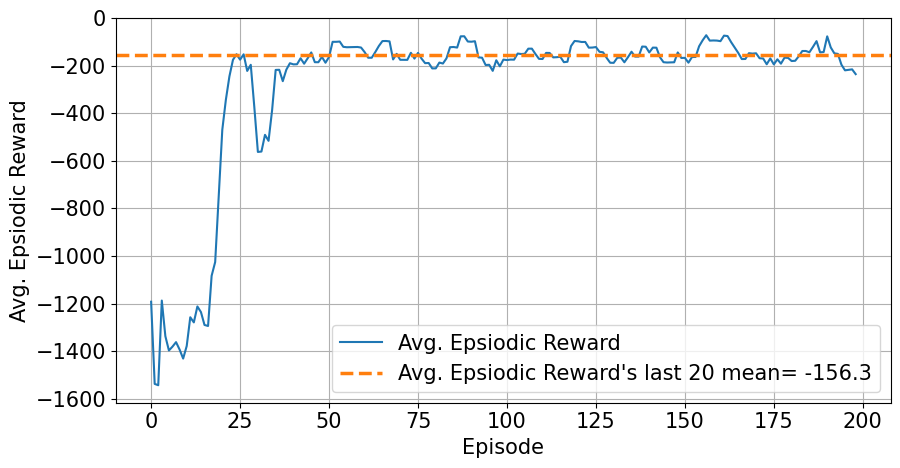

In [ ]:
# Plotting graph
# Episodes versus Avg. Rewards
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(avg_reward_list, label = "Avg. Epsiodic Reward",color="C0",linewidth = 1.5)
plt.axhline(y=np.array(avg_reward_list)[-20:-1].mean(), linestyle='--',
            label = "Avg. Epsiodic Reward's last 20 mean= "+f"{np.array(avg_reward_list)[-20:-1].mean():.1f}",color="C1",linewidth = 2.5)
plt.xlabel("Episode")
plt.ylabel("Avg. Epsiodic Reward")
plt.grid()
plt.legend()
plt.show()

In [ ]:
print("Avg. Epsiodic Reward's last 20 mean=")
print(np.array(avg_reward_list)[-20:-1].mean())

Avg. Epsiodic Reward's last 20 mean=
-156.25425975808218


In [ ]:
if not env.ideal_env:
  font = {'size': 15}
  plt.rc('font', **font)
  f = plt.figure()
  f.set_figwidth(10)
  f.set_figheight(5)
  plt.plot(avg_ep_abs_error_action_list, label = "Avg. Ep. Action Abs Error",color="C0",linewidth = 1.5)
  plt.axhline(y=np.array(avg_ep_abs_error_action_list)[-20:-1].mean(), linestyle='--',
            label = "Avg. Ep. Action Abs Error's last 20 mean= "+f"{np.array(avg_ep_abs_error_action_list)[-20:-1].mean():.2e}",color="C1",linewidth = 2.5)
  plt.xlabel("Episode")
  plt.ylabel("Avg. Ep. Action Abs Error")
  plt.grid()
  plt.legend()
  plt.show()

In [ ]:
if not env.ideal_env:
  print("Avg. Ep. Action Abs Error's last 20 mean=")
  print(np.array(avg_ep_abs_error_action_list)[-20:-1].mean())

In [ ]:
dt = env.dt
#dt=0.05

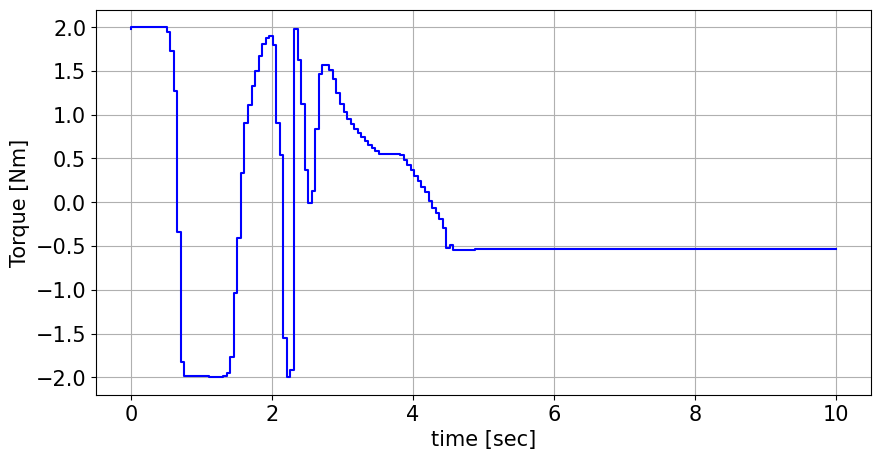

In [ ]:
time_position_u1= np.linspace(start = 0, stop = len(save_u1)* dt,num=len(save_u1) )
time_position__pid_u1= np.linspace(start = 0, stop = len(save_u1)* dt,num=len(save_u1) )

font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.step(time_position_u1, save_u1 ,label = "desired_torque",color="blue",linewidth = 1.5)
plt.xlabel("time [sec]")
plt.ylabel("Torque [Nm]")
if not env.ideal_env:
  plt.step(time_position__pid_u1, save_pid_u1 , ':',label = "actual_torque",color="red",linewidth = 4)
  mae_torque_error = np.array(save_u1)-np.array(save_pid_u1)
  mae_torque_error = np.abs(mae_torque_error).mean()
  plt.axhline(y=mae_torque_error, linestyle='--',
            label = "MAE_torque_error= "+f"{mae_torque_error:.2e}",color="C1",linewidth = 2.5)
  plt.legend()
plt.grid()
plt.show()

In [ ]:
if not env.ideal_env:
  print("MAE torque error=", mae_torque_error)

In [ ]:
import math

x_print = []
y_print = []
thetadot_print = []

for observ in save_observation:
  for index,value in enumerate(observ):
    if index == 0:
      x_print.append(value)
      #theta_print.append(math.acos(value))
    if index == 1:
      y_print.append(value)
    if index == 2:
      thetadot_print.append(value)

theta_print = list(np.arctan2(np.array(y_print), np.array(x_print)))

In [ ]:
print(len(x_print))

200


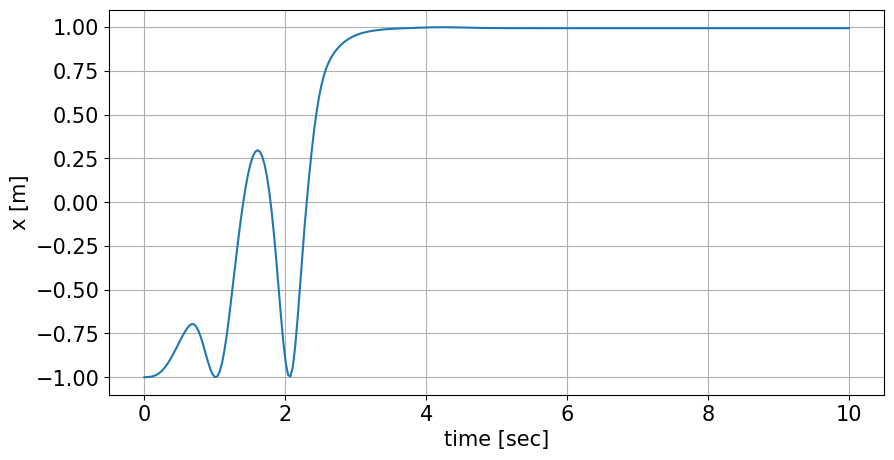

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_x_print = np.linspace(start = 0, stop = len(x_print)* dt,num=len(x_print))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_x_print[-1] , 300)

spl = make_interp_spline(time_x_print, x_print, k=3)  # type: BSpline
power_smooth = spl(xnew)

font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.plot(xnew, power_smooth)
plt.xlabel("time [sec]")
plt.ylabel("x [m]")
plt.grid()
plt.show()

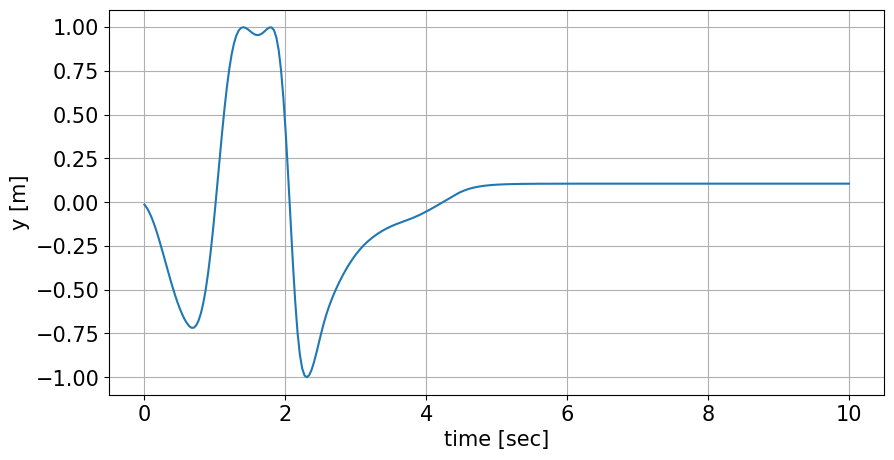

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_y_print = np.linspace(start = 0, stop = len(y_print)* dt,num=len(y_print))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_y_print[-1] , 300)

spl = make_interp_spline(time_y_print, y_print, k=3)  # type: BSpline
power_smooth = spl(xnew)

font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.plot(xnew, power_smooth)
plt.xlabel("time [sec]")
plt.ylabel("y [m]")
plt.grid()
plt.show()

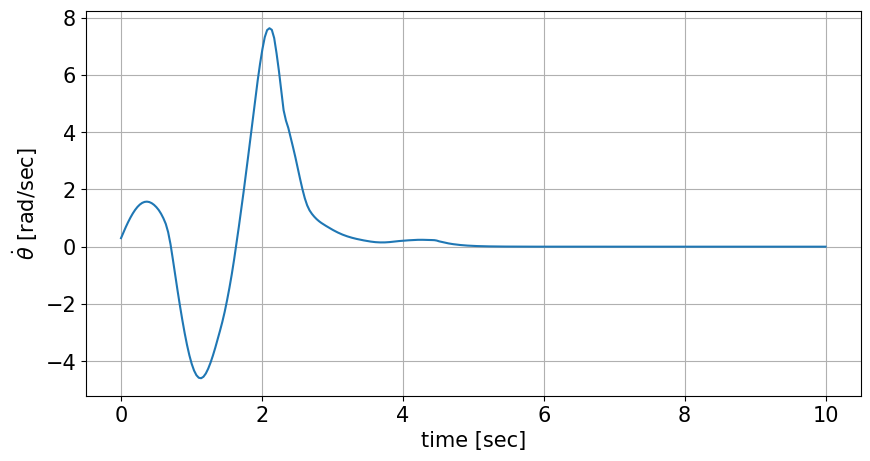

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_thetadot_print = np.linspace(start = 0, stop = len(thetadot_print)* dt,num=len(thetadot_print))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_thetadot_print[-1] , 300)

spl = make_interp_spline(time_thetadot_print, thetadot_print, k=3)  # type: BSpline
power_smooth = spl(xnew)

font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.plot(xnew, power_smooth)
plt.xlabel("time [sec]")
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.ylabel(r'$\dot{\theta}$ [rad/sec]')
plt.grid()
plt.show()

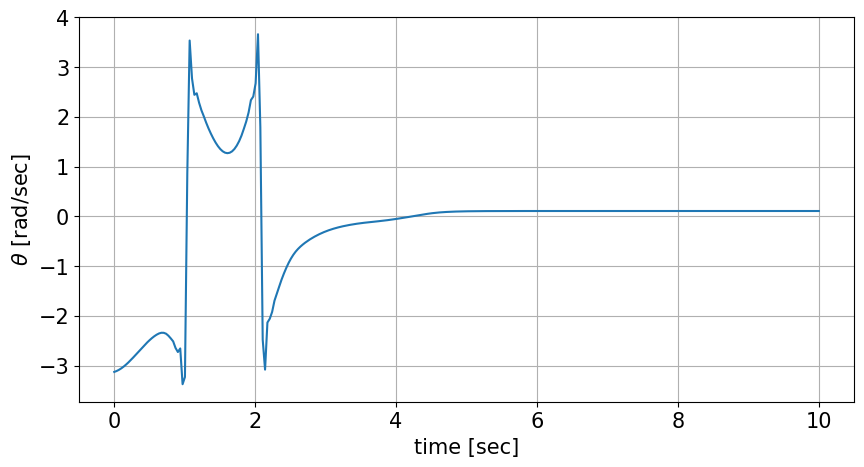

In [ ]:
time_theta_print = np.linspace(start = 0, stop = len(theta_print)* dt,num=len(theta_print))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_theta_print[-1] , 300)

spl = make_interp_spline(time_theta_print, theta_print, k=3)  # type: BSpline
power_smooth = spl(xnew)

font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.plot(xnew, power_smooth)
plt.xlabel("time [sec]")
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.ylabel(r'$\theta$ [rad/sec]')
plt.grid()
plt.show()

In [ ]:
policy.actor=torch.load('model.pickle',weights_only=False).to(device)

##Ideal Env Test

In [ ]:
episodes=30

In [ ]:
train_mode = False
env.ideal_env = True
#env.DCMotorModel.Kp = 1.0
#env.DCMotorModel.Ki = 20.0
#env.DCMotorModel.Kd = 10**(-6)
#env.DCMotorModel.Kr = 0.0
#env.DCMotorModel.Kw = 1.0

In [ ]:
total_time = 0
episode = 0
done = True

t_0 = time.time()

save_observation = []
save_u1 = []
save_pid_u1 = []

rewards = []
avg_reward_list = []
score = deque(maxlen=5)
best_score = -10000
ep_abs_error_action_list = []
avg_ep_abs_error_action_list = []

beta_value = 0
while episode<episodes:
#while total_time < train_steps:

    if done:
        if total_time != 0:
            rewards.append(episode_r)
            score.appendleft(episode_r)
            if episode <5:
                np_mean_score = episode_r
            else:
                np_mean_score = np.mean(score)
            avg_reward_list.append(np_mean_score)
            if not env.ideal_env:
                ep_abs_error_action_list.append(episodic_abs_error_action/(episode_t+1))
                avg_ep_abs_error = np.mean(ep_abs_error_action_list[-10:])
                avg_ep_abs_error_action_list.append(avg_ep_abs_error)
            if verbose:
                print("Ep "+str(episode)+"  Total Time Steps: "+str(total_time))
                print(f" Episode Reward: {episode_r:.2f}, mean 5: {np_mean_score:.2f}")
                if not env.ideal_env:
                    print(" Avg Action Abs Error: {}".format(f"{avg_ep_abs_error:.2e}"))
                print(" Runtime: "+str(int(time.time() - t_0)))
            if train_mode and np_mean_score > best_score and episode >= 5:
                torch.save(policy.actor, "model.pickle")
                best_score = np_mean_score
                if verbose:
                  print(' updated!!!!', f"{best_score:.2f}", '---------------------')

            if train_mode:
                #set beta value used for importance sampling weights
                if prioritized:
                    beta_value = beta_schedule.value(total_time)
                #train DDPG
                policy.train(replay_buffer, prioritized, beta_value, prioritized_replay_eps, episode_t, batch_size, gamma,
                             double_critic=True)

        #reset environment
        #get intial state
        #reset episode statistics
        s = env.reset()
        done = False
        episode_r = 0
        episode_t = 0
        episode += 1
        episodic_abs_error_action = 0
        #n_count = 1
        if episode == episodes - 1:
            env.state = np.array([3.14,0])
            s = env._get_obs()

    '''
    at time t, choose action a, observe new state s_new and new reward r
    and store to buffer
    '''
    #Given current state, get action
    a = policy.get_action(np.array(s))
    #Apply exploration noise to action
    #a = (a + np.random.normal(0, 0.1, size=env.action_space.shape[0])).clip(env.action_space.low, env.action_space.high)
    #Using action, take step in environment, observe new state, reward and episode status
    s_new, r, done, _, u , u_after_pid = env.step(a)
    done_bool = 0 if episode_t + 1 == env.max_step else float(done)
    episode_r += r

    if episode == episodes - 1 :
        save_observation.append(s_new)
        save_u1.append(u)
        save_pid_u1.append(u_after_pid)

    if not env.ideal_env:
        episodic_abs_error_action += abs(u-u_after_pid)
        #episodic_abs_error_action += (abs(u-u_after_pid)-episodic_abs_error_action)/n_count
        #n_count+=1

    if train_mode:
        # Store data in replay buffer
        if not prioritized:
            #try:
            #    replay_buffer.add((s, a, r, s_new, done_bool))
            #except ValueError:
            replay_buffer.add((s, a, np.array(r).reshape(-1, 1), s_new, np.array(done_bool).reshape(-1, 1)))
        else:
            replay_buffer.add(s, a, r, s_new, done_bool)

    #update state and episode statistics
    s = s_new
    episode_t += 1
    total_time += 1


Ep 1  Total Time Steps: 199
 Episode Reward: -244.83, mean 5: -244.83
 Runtime: 0
Ep 2  Total Time Steps: 399
 Episode Reward: -119.79, mean 5: -119.79
 Runtime: 0
Ep 3  Total Time Steps: 599
 Episode Reward: -119.09, mean 5: -119.09
 Runtime: 0
Ep 4  Total Time Steps: 799
 Episode Reward: -337.58, mean 5: -337.58
 Runtime: 0
Ep 5  Total Time Steps: 999
 Episode Reward: -230.41, mean 5: -210.34
 Runtime: 0
Ep 6  Total Time Steps: 1199
 Episode Reward: -120.34, mean 5: -185.44
 Runtime: 0
Ep 7  Total Time Steps: 1399
 Episode Reward: -127.27, mean 5: -186.94
 Runtime: 0
Ep 8  Total Time Steps: 1599
 Episode Reward: -120.02, mean 5: -187.12
 Runtime: 0
Ep 9  Total Time Steps: 1799
 Episode Reward: -1.46, mean 5: -119.90
 Runtime: 0
Ep 10  Total Time Steps: 1999
 Episode Reward: -332.03, mean 5: -140.22
 Runtime: 0
Ep 11  Total Time Steps: 2199
 Episode Reward: -233.15, mean 5: -162.78
 Runtime: 1
Ep 12  Total Time Steps: 2399
 Episode Reward: -0.84, mean 5: -137.50
 Runtime: 1
Ep 13  Tot

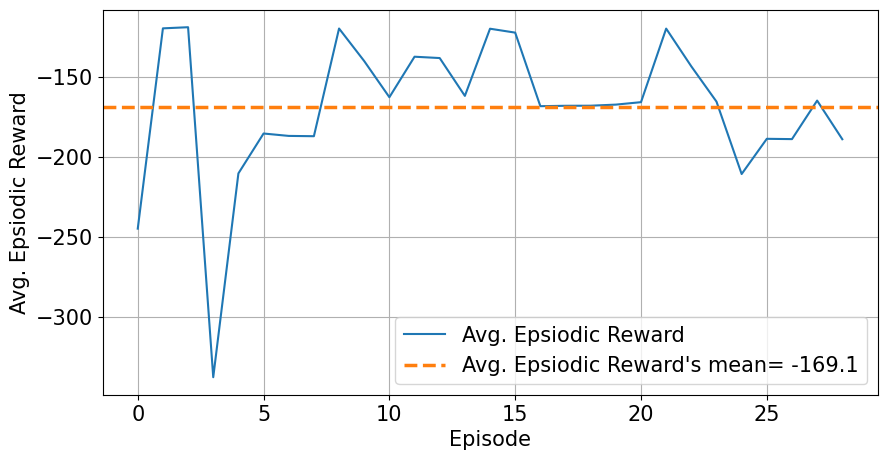

In [ ]:
# Plotting graph
# Episodes versus Avg. Rewards
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(avg_reward_list, label = "Avg. Epsiodic Reward",color="C0",linewidth = 1.5)
plt.axhline(y=np.array(avg_reward_list).mean(), linestyle='--',
            label = "Avg. Epsiodic Reward's mean= "+f"{np.array(avg_reward_list).mean():.1f}",color="C1",linewidth = 2.5)
plt.xlabel("Episode")
plt.ylabel("Avg. Epsiodic Reward")
plt.grid()
plt.legend()
plt.show()

In [ ]:
print("Avg. Epsiodic Reward's mean=")
print(np.array(avg_reward_list).mean())

Avg. Epsiodic Reward's mean=
-169.08701483355316


In [ ]:
if not env.ideal_env:
  font = {'size': 15}
  plt.rc('font', **font)
  f = plt.figure()
  f.set_figwidth(10)
  f.set_figheight(5)
  plt.plot(avg_ep_abs_error_action_list, label = "Avg. Ep. Action Abs Error",color="C0",linewidth = 1.5)
  plt.axhline(y=np.array(avg_ep_abs_error_action_list).mean(), linestyle='--',
            label = "Avg. Ep. Action Abs Error's mean= "+f"{np.array(avg_ep_abs_error_action_list).mean():.2e}",color="C1",linewidth = 2.5)
  plt.xlabel("Episode")
  plt.ylabel("Avg. Ep. Action Abs Error")
  plt.grid()
  plt.legend()
  plt.show()

In [ ]:
if not env.ideal_env:
  print("Avg. Ep. Action Abs Error's mean=")
  print(np.array(avg_ep_abs_error_action_list).mean())

In [ ]:
dt = env.dt
#dt=0.05

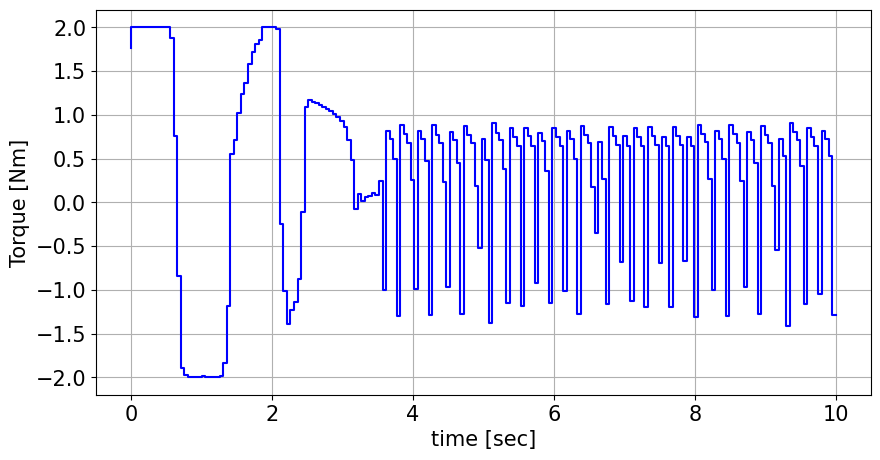

In [ ]:
time_position_u1= np.linspace(start = 0, stop = len(save_u1)* dt,num=len(save_u1) )
time_position__pid_u1= np.linspace(start = 0, stop = len(save_u1)* dt,num=len(save_u1) )

font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.step(time_position_u1, save_u1 ,label = "desired_torque",color="blue",linewidth = 1.5)
plt.xlabel("time [sec]")
plt.ylabel("Torque [Nm]")
if not env.ideal_env:
  plt.step(time_position__pid_u1, save_pid_u1 , ':',label = "actual_torque",color="red",linewidth = 4)
  mae_torque_error = np.array(save_u1)-np.array(save_pid_u1)
  mae_torque_error = np.abs(mae_torque_error).mean()
  plt.axhline(y=mae_torque_error, linestyle='--',
            label = "MAE_torque_error= "+f"{mae_torque_error:.2e}",color="C1",linewidth = 2.5)
  plt.legend()
plt.grid()
plt.show()

In [ ]:
if not env.ideal_env:
  print("MAE torque error=", mae_torque_error)

In [ ]:
import math

x_print = []
y_print = []
thetadot_print = []

for observ in save_observation:
  for index,value in enumerate(observ):
    if index == 0:
      x_print.append(value)
      #theta_print.append(math.acos(value))
    if index == 1:
      y_print.append(value)
    if index == 2:
      thetadot_print.append(value)

theta_print = list(np.arctan2(np.array(y_print), np.array(x_print)))

In [ ]:
print(len(x_print))

200


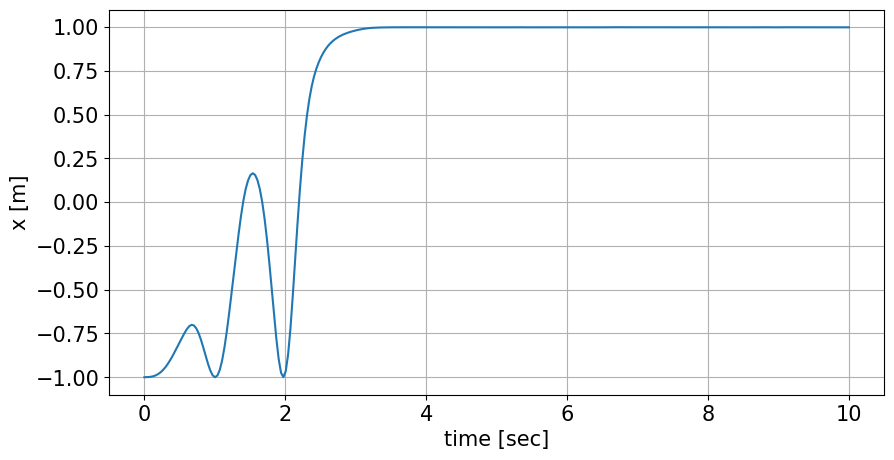

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_x_print = np.linspace(start = 0, stop = len(x_print)* dt,num=len(x_print))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_x_print[-1] , 300)

spl = make_interp_spline(time_x_print, x_print, k=3)  # type: BSpline
power_smooth = spl(xnew)

font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.plot(xnew, power_smooth)
plt.xlabel("time [sec]")
plt.ylabel("x [m]")
plt.grid()
plt.show()

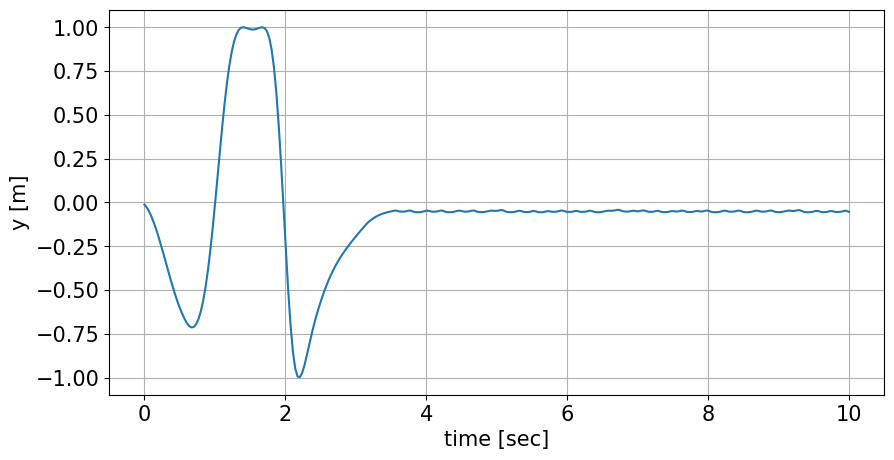

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_y_print = np.linspace(start = 0, stop = len(y_print)* dt,num=len(y_print))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_y_print[-1] , 300)

spl = make_interp_spline(time_y_print, y_print, k=3)  # type: BSpline
power_smooth = spl(xnew)

font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.plot(xnew, power_smooth)
plt.xlabel("time [sec]")
plt.ylabel("y [m]")
plt.grid()
plt.show()

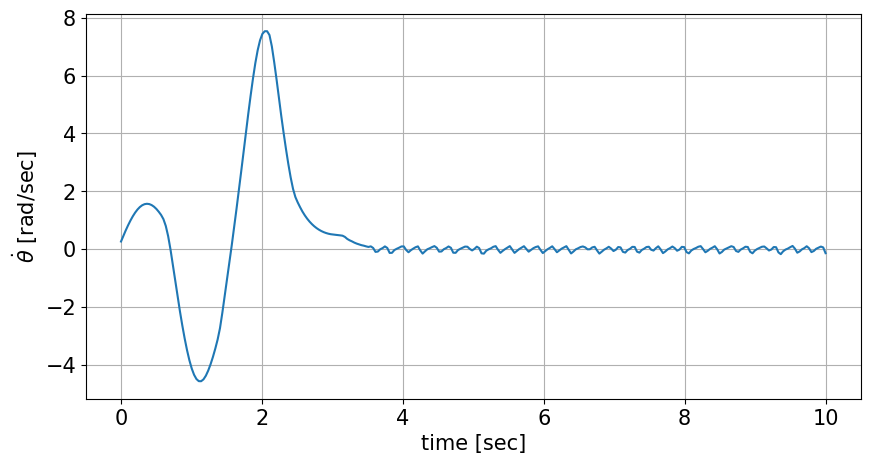

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_thetadot_print = np.linspace(start = 0, stop = len(thetadot_print)* dt,num=len(thetadot_print))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_thetadot_print[-1] , 300)

spl = make_interp_spline(time_thetadot_print, thetadot_print, k=3)  # type: BSpline
power_smooth = spl(xnew)

font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.plot(xnew, power_smooth)
plt.xlabel("time [sec]")
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.ylabel(r'$\dot{\theta}$ [rad/sec]')
plt.grid()
plt.show()

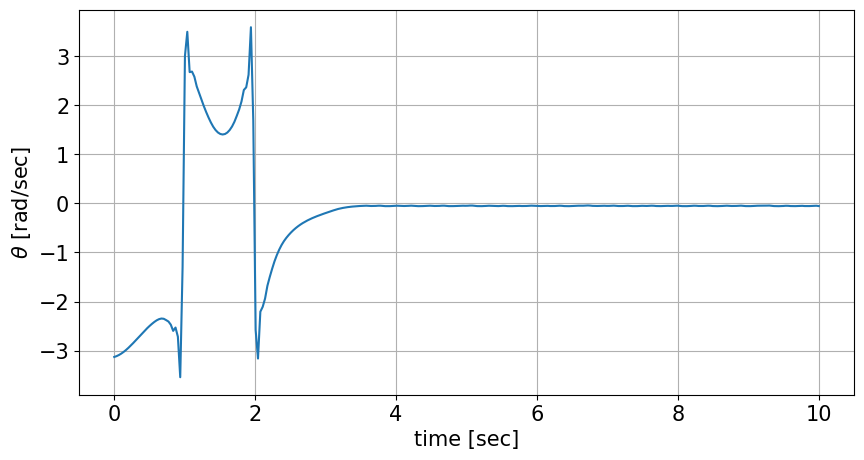

In [ ]:
time_theta_print = np.linspace(start = 0, stop = len(theta_print)* dt,num=len(theta_print))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_theta_print[-1] , 300)

spl = make_interp_spline(time_theta_print, theta_print, k=3)  # type: BSpline
power_smooth = spl(xnew)

font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.plot(xnew, power_smooth)
plt.xlabel("time [sec]")
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.ylabel(r'$\theta$ [rad/sec]')
plt.grid()
plt.show()

##Actual Env Test with PID ctrl

In [ ]:
train_mode = False
env.ideal_env = False
env.DCMotorModel.Kp = 1.0
env.DCMotorModel.Ki = 20.0
env.DCMotorModel.Kd = 10**(-6)
env.DCMotorModel.Kr = 0.0
env.DCMotorModel.Kw = 1.0

In [ ]:
total_time = 0
episode = 0
done = True

t_0 = time.time()

save_observation = []
save_u1 = []
save_pid_u1 = []

rewards = []
avg_reward_list = []
score = deque(maxlen=5)
best_score = -10000
ep_abs_error_action_list = []
avg_ep_abs_error_action_list = []

beta_value = 0
while episode<episodes:
#while total_time < train_steps:

    if done:
        if total_time != 0:
            rewards.append(episode_r)
            score.appendleft(episode_r)
            if episode <5:
                np_mean_score = episode_r
            else:
                np_mean_score = np.mean(score)
            avg_reward_list.append(np_mean_score)
            if not env.ideal_env:
                ep_abs_error_action_list.append(episodic_abs_error_action/(episode_t+1))
                avg_ep_abs_error = np.mean(ep_abs_error_action_list[-10:])
                avg_ep_abs_error_action_list.append(avg_ep_abs_error)
            if verbose:
                print("Ep "+str(episode)+"  Total Time Steps: "+str(total_time))
                print(f" Episode Reward: {episode_r:.2f}, mean 5: {np_mean_score:.2f}")
                if not env.ideal_env:
                    print(" Avg Action Abs Error: {}".format(f"{avg_ep_abs_error:.2e}"))
                print(" Runtime: "+str(int(time.time() - t_0)))
            if train_mode and np_mean_score > best_score and episode >= 5:
                torch.save(policy.actor, "model.pickle")
                best_score = np_mean_score
                if verbose:
                  print(' updated!!!!', f"{best_score:.2f}", '---------------------')

            if train_mode:
                #set beta value used for importance sampling weights
                if prioritized:
                    beta_value = beta_schedule.value(total_time)
                #train DDPG
                policy.train(replay_buffer, prioritized, beta_value, prioritized_replay_eps, episode_t, batch_size, gamma,
                             double_critic=True)

        #reset environment
        #get intial state
        #reset episode statistics
        s = env.reset()
        done = False
        episode_r = 0
        episode_t = 0
        episode += 1
        episodic_abs_error_action = 0
        #n_count = 1
        if episode == episodes - 1:
            env.state = np.array([3.14,0])
            s = env._get_obs()

    '''
    at time t, choose action a, observe new state s_new and new reward r
    and store to buffer
    '''
    #Given current state, get action
    a = policy.get_action(np.array(s))
    #Apply exploration noise to action
    #a = (a + np.random.normal(0, 0.1, size=env.action_space.shape[0])).clip(env.action_space.low, env.action_space.high)
    #Using action, take step in environment, observe new state, reward and episode status
    s_new, r, done, _, u , u_after_pid = env.step(a)
    done_bool = 0 if episode_t + 1 == env.max_step else float(done)
    episode_r += r

    if episode == episodes - 1 :
        save_observation.append(s_new)
        save_u1.append(u)
        save_pid_u1.append(u_after_pid)

    if not env.ideal_env:
        episodic_abs_error_action += abs(u-u_after_pid)
        #episodic_abs_error_action += (abs(u-u_after_pid)-episodic_abs_error_action)/n_count
        #n_count+=1

    if train_mode:
        # Store data in replay buffer
        if not prioritized:
            #try:
            #    replay_buffer.add((s, a, r, s_new, done_bool))
            #except ValueError:
            replay_buffer.add((s, a, np.array(r).reshape(-1, 1), s_new, np.array(done_bool).reshape(-1, 1)))
        else:
            replay_buffer.add(s, a, r, s_new, done_bool)

    #update state and episode statistics
    s = s_new
    episode_t += 1
    total_time += 1


Ep 1  Total Time Steps: 199
 Episode Reward: -126.33, mean 5: -126.33
 Avg Action Abs Error: 2.31e-05
 Runtime: 0
Ep 2  Total Time Steps: 399
 Episode Reward: -120.11, mean 5: -120.11
 Avg Action Abs Error: 1.99e-05
 Runtime: 0
Ep 3  Total Time Steps: 599
 Episode Reward: -120.01, mean 5: -120.01
 Avg Action Abs Error: 1.98e-05
 Runtime: 0
Ep 4  Total Time Steps: 799
 Episode Reward: -0.90, mean 5: -0.90
 Avg Action Abs Error: 2.00e-05
 Runtime: 0
Ep 5  Total Time Steps: 999
 Episode Reward: -222.23, mean 5: -117.92
 Avg Action Abs Error: 1.91e-05
 Runtime: 0
Ep 6  Total Time Steps: 1199
 Episode Reward: -307.45, mean 5: -154.14
 Avg Action Abs Error: 1.84e-05
 Runtime: 0
Ep 7  Total Time Steps: 1399
 Episode Reward: -115.40, mean 5: -153.20
 Avg Action Abs Error: 1.80e-05
 Runtime: 0
Ep 8  Total Time Steps: 1599
 Episode Reward: -125.02, mean 5: -154.20
 Avg Action Abs Error: 2.59e-05
 Runtime: 0
Ep 9  Total Time Steps: 1799
 Episode Reward: -115.54, mean 5: -177.13
 Avg Action Abs Er

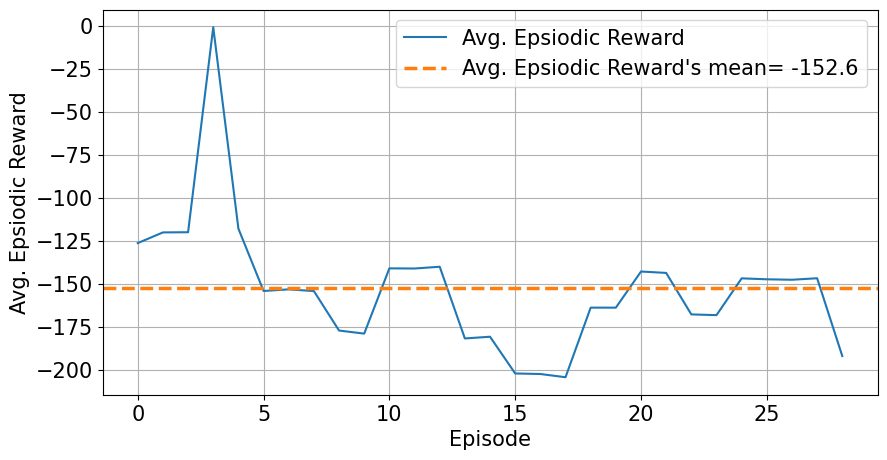

In [ ]:
## Plotting graph
# Episodes versus Avg. Rewards
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(avg_reward_list, label = "Avg. Epsiodic Reward",color="C0",linewidth = 1.5)
plt.axhline(y=np.array(avg_reward_list).mean(), linestyle='--',
            label = "Avg. Epsiodic Reward's mean= "+f"{np.array(avg_reward_list).mean():.1f}",color="C1",linewidth = 2.5)
plt.xlabel("Episode")
plt.ylabel("Avg. Epsiodic Reward")
plt.grid()
plt.legend()
plt.show()

In [ ]:
print("Avg. Epsiodic Reward's mean=")
print(np.array(avg_reward_list).mean())

Avg. Epsiodic Reward's mean=
-152.64405971198218


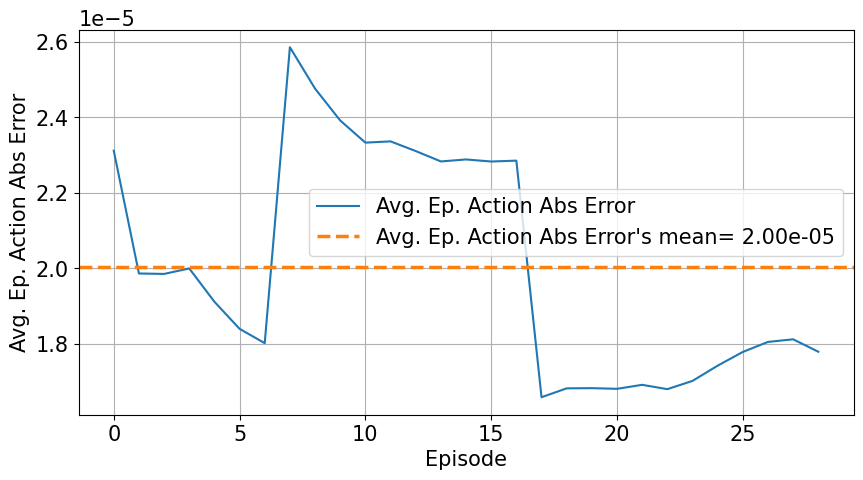

In [ ]:
if not env.ideal_env:
  font = {'size': 15}
  plt.rc('font', **font)
  f = plt.figure()
  f.set_figwidth(10)
  f.set_figheight(5)
  plt.plot(avg_ep_abs_error_action_list, label = "Avg. Ep. Action Abs Error",color="C0",linewidth = 1.5)
  plt.axhline(y=np.array(avg_ep_abs_error_action_list).mean(), linestyle='--',
            label = "Avg. Ep. Action Abs Error's mean= "+f"{np.array(avg_ep_abs_error_action_list).mean():.2e}",color="C1",linewidth = 2.5)
  plt.xlabel("Episode")
  plt.ylabel("Avg. Ep. Action Abs Error")
  plt.grid()
  plt.legend()
  plt.show()

In [ ]:
if not env.ideal_env:
  print("Avg. Ep. Action Abs Error's mean=")
  print(np.array(avg_ep_abs_error_action_list).mean())

Avg. Ep. Action Abs Error's mean=
2.0029978892597627e-05


In [ ]:
dt = env.dt
#dt=0.05

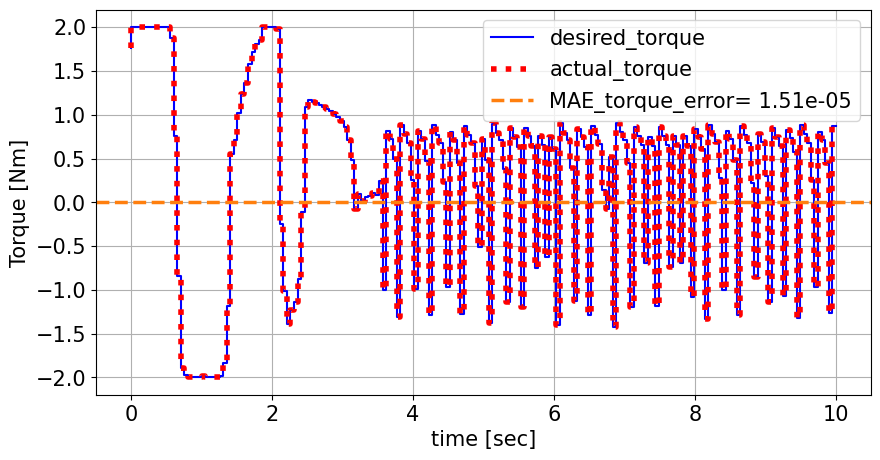

In [ ]:
time_position_u1= np.linspace(start = 0, stop = len(save_u1)* dt,num=len(save_u1) )
time_position__pid_u1= np.linspace(start = 0, stop = len(save_u1)* dt,num=len(save_u1) )

font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.step(time_position_u1, save_u1 ,label = "desired_torque",color="blue",linewidth = 1.5)
plt.xlabel("time [sec]")
plt.ylabel("Torque [Nm]")
if not env.ideal_env:
  plt.step(time_position__pid_u1, save_pid_u1 , ':',label = "actual_torque",color="red",linewidth = 4)
  mae_torque_error = np.array(save_u1)-np.array(save_pid_u1)
  mae_torque_error = np.abs(mae_torque_error).mean()
  plt.axhline(y=mae_torque_error, linestyle='--',
            label = "MAE_torque_error= "+f"{mae_torque_error:.2e}",color="C1",linewidth = 2.5)
  plt.legend()
plt.grid()
plt.show()

In [ ]:
if not env.ideal_env:
  print("MAE torque error=", mae_torque_error)

MAE torque error= 1.5106175606184915e-05


In [ ]:
import math

x_print = []
y_print = []
thetadot_print = []

for observ in save_observation:
  for index,value in enumerate(observ):
    if index == 0:
      x_print.append(value)
      #theta_print.append(math.acos(value))
    if index == 1:
      y_print.append(value)
    if index == 2:
      thetadot_print.append(value)

theta_print = list(np.arctan2(np.array(y_print), np.array(x_print)))

In [ ]:
print(len(x_print))

200


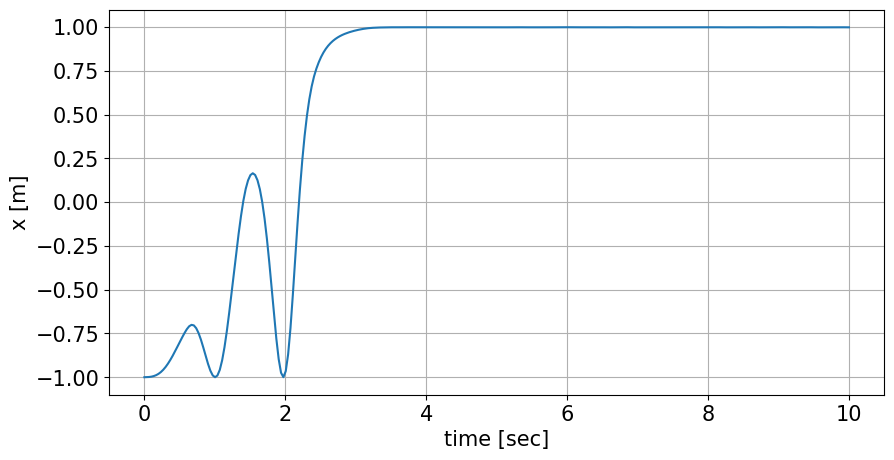

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_x_print = np.linspace(start = 0, stop = len(x_print)* dt,num=len(x_print))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_x_print[-1] , 300)

spl = make_interp_spline(time_x_print, x_print, k=3)  # type: BSpline
power_smooth = spl(xnew)

font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.plot(xnew, power_smooth)
plt.xlabel("time [sec]")
plt.ylabel("x [m]")
plt.grid()
plt.show()

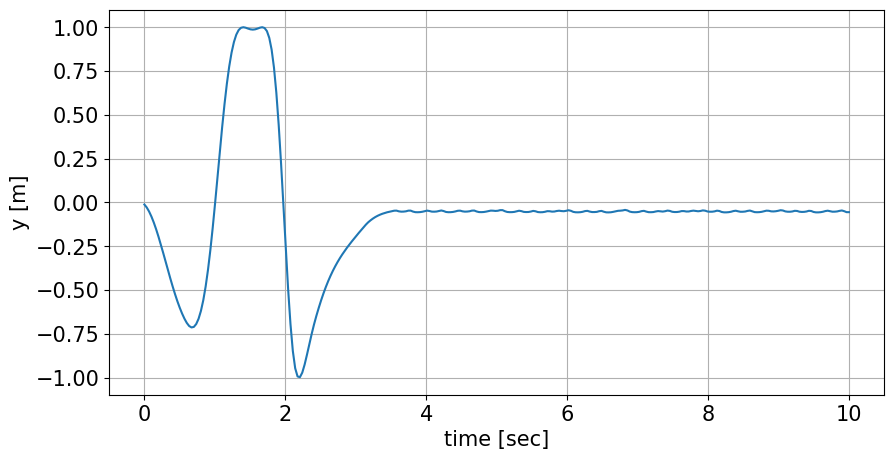

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_y_print = np.linspace(start = 0, stop = len(y_print)* dt,num=len(y_print))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_y_print[-1] , 300)

spl = make_interp_spline(time_y_print, y_print, k=3)  # type: BSpline
power_smooth = spl(xnew)

font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.plot(xnew, power_smooth)
plt.xlabel("time [sec]")
plt.ylabel("y [m]")
plt.grid()
plt.show()

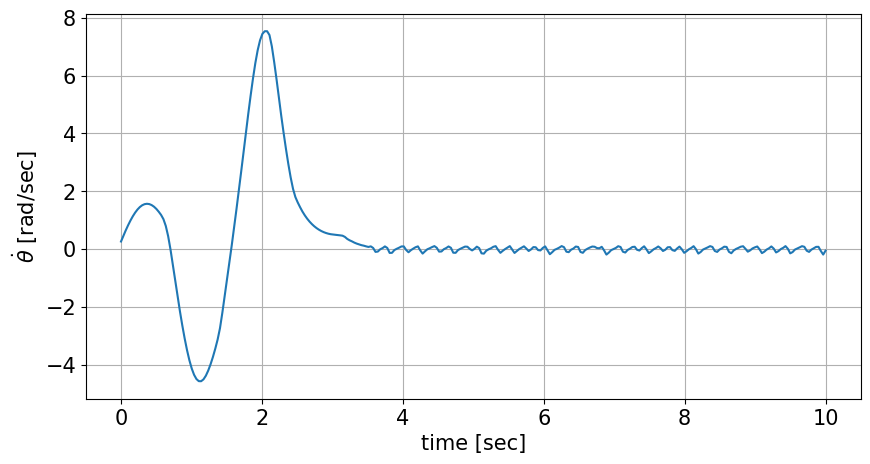

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_thetadot_print = np.linspace(start = 0, stop = len(thetadot_print)* dt,num=len(thetadot_print))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_thetadot_print[-1] , 300)

spl = make_interp_spline(time_thetadot_print, thetadot_print, k=3)  # type: BSpline
power_smooth = spl(xnew)

font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.plot(xnew, power_smooth)
plt.xlabel("time [sec]")
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.ylabel(r'$\dot{\theta}$ [rad/sec]')
plt.grid()
plt.show()

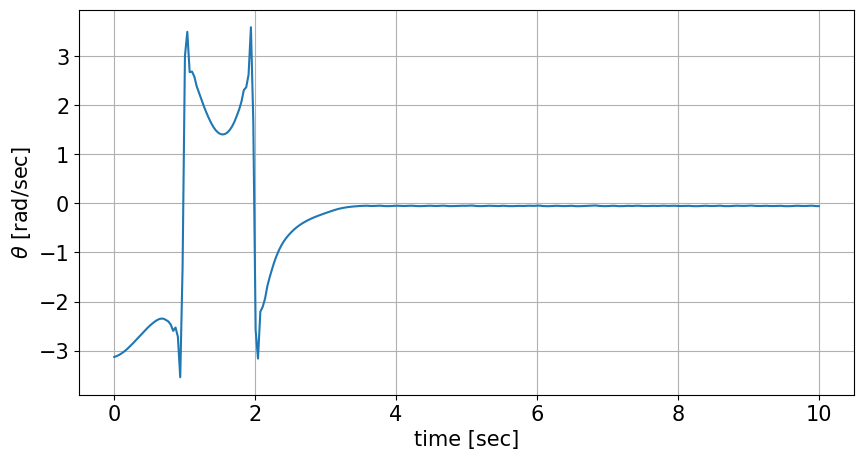

In [ ]:
time_theta_print = np.linspace(start = 0, stop = len(theta_print)* dt,num=len(theta_print))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_theta_print[-1] , 300)

spl = make_interp_spline(time_theta_print, theta_print, k=3)  # type: BSpline
power_smooth = spl(xnew)

font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.plot(xnew, power_smooth)
plt.xlabel("time [sec]")
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.ylabel(r'$\theta$ [rad/sec]')
plt.grid()
plt.show()

## Actual Env Test Feed-fwd only u_ctrl=K*action_RL

In [ ]:
train_mode = False
env.ideal_env = False
env.DCMotorModel.Kp = 0.0#1.0
env.DCMotorModel.Ki = 0.0#20.0
env.DCMotorModel.Kd = 0.0#10**(-6)
env.DCMotorModel.Kr = 1.0#0.0
env.DCMotorModel.Kw = 0.0#1.0

In [ ]:
total_time = 0
episode = 0
done = True

t_0 = time.time()

save_observation = []
save_u1 = []
save_pid_u1 = []

rewards = []
avg_reward_list = []
score = deque(maxlen=5)
best_score = -10000
ep_abs_error_action_list = []
avg_ep_abs_error_action_list = []

beta_value = 0
while episode<episodes:
#while total_time < train_steps:

    if done:
        if total_time != 0:
            rewards.append(episode_r)
            score.appendleft(episode_r)
            if episode <5:
                np_mean_score = episode_r
            else:
                np_mean_score = np.mean(score)
            avg_reward_list.append(np_mean_score)
            if not env.ideal_env:
                ep_abs_error_action_list.append(episodic_abs_error_action/(episode_t+1))
                avg_ep_abs_error = np.mean(ep_abs_error_action_list[-10:])
                avg_ep_abs_error_action_list.append(avg_ep_abs_error)
            if verbose:
                print("Ep "+str(episode)+"  Total Time Steps: "+str(total_time))
                print(f" Episode Reward: {episode_r:.2f}, mean 5: {np_mean_score:.2f}")
                if not env.ideal_env:
                    print(" Avg Action Abs Error: {}".format(f"{avg_ep_abs_error:.2e}"))
                print(" Runtime: "+str(int(time.time() - t_0)))
            if train_mode and np_mean_score > best_score and episode >= 5:
                torch.save(policy.actor, "model.pickle")
                best_score = np_mean_score
                if verbose:
                  print(' updated!!!!', f"{best_score:.2f}", '---------------------')

            if train_mode:
                #set beta value used for importance sampling weights
                if prioritized:
                    beta_value = beta_schedule.value(total_time)
                #train DDPG
                policy.train(replay_buffer, prioritized, beta_value, prioritized_replay_eps, episode_t, batch_size, gamma,
                             double_critic=True)

        #reset environment
        #get intial state
        #reset episode statistics
        s = env.reset()
        done = False
        episode_r = 0
        episode_t = 0
        episode += 1
        episodic_abs_error_action = 0
        #n_count = 1
        if episode == episodes - 1:
            env.state = np.array([3.14,0])
            s = env._get_obs()

    '''
    at time t, choose action a, observe new state s_new and new reward r
    and store to buffer
    '''
    #Given current state, get action
    a = policy.get_action(np.array(s))
    #Apply exploration noise to action
    #a = (a + np.random.normal(0, 0.1, size=env.action_space.shape[0])).clip(env.action_space.low, env.action_space.high)
    #Using action, take step in environment, observe new state, reward and episode status
    s_new, r, done, _, u , u_after_pid = env.step(a)
    done_bool = 0 if episode_t + 1 == env.max_step else float(done)
    episode_r += r

    if episode == episodes - 1 :
        save_observation.append(s_new)
        save_u1.append(u)
        save_pid_u1.append(u_after_pid)

    if not env.ideal_env:
        episodic_abs_error_action += abs(u-u_after_pid)
        #episodic_abs_error_action += (abs(u-u_after_pid)-episodic_abs_error_action)/n_count
        #n_count+=1

    if train_mode:
        # Store data in replay buffer
        if not prioritized:
            #try:
            #    replay_buffer.add((s, a, r, s_new, done_bool))
            #except ValueError:
            replay_buffer.add((s, a, np.array(r).reshape(-1, 1), s_new, np.array(done_bool).reshape(-1, 1)))
        else:
            replay_buffer.add(s, a, r, s_new, done_bool)

    #update state and episode statistics
    s = s_new
    episode_t += 1
    total_time += 1

Ep 1  Total Time Steps: 199
 Episode Reward: -4.78, mean 5: -4.78
 Avg Action Abs Error: 2.81e-01
 Runtime: 0
Ep 2  Total Time Steps: 399
 Episode Reward: -1575.53, mean 5: -1575.53
 Avg Action Abs Error: 9.53e-01
 Runtime: 0
Ep 3  Total Time Steps: 599
 Episode Reward: -1567.27, mean 5: -1567.27
 Avg Action Abs Error: 1.18e+00
 Runtime: 0
Ep 4  Total Time Steps: 799
 Episode Reward: -1554.72, mean 5: -1554.72
 Avg Action Abs Error: 1.32e+00
 Runtime: 0
Ep 5  Total Time Steps: 999
 Episode Reward: -1571.95, mean 5: -1254.85
 Avg Action Abs Error: 1.39e+00
 Runtime: 0
Ep 6  Total Time Steps: 1199
 Episode Reward: -0.90, mean 5: -1254.07
 Avg Action Abs Error: 1.22e+00
 Runtime: 0
Ep 7  Total Time Steps: 1399
 Episode Reward: -1562.80, mean 5: -1251.53
 Avg Action Abs Error: 1.28e+00
 Runtime: 0
Ep 8  Total Time Steps: 1599
 Episode Reward: -1569.49, mean 5: -1251.97
 Avg Action Abs Error: 1.33e+00
 Runtime: 1
Ep 9  Total Time Steps: 1799
 Episode Reward: -1522.74, mean 5: -1245.57
 Avg 

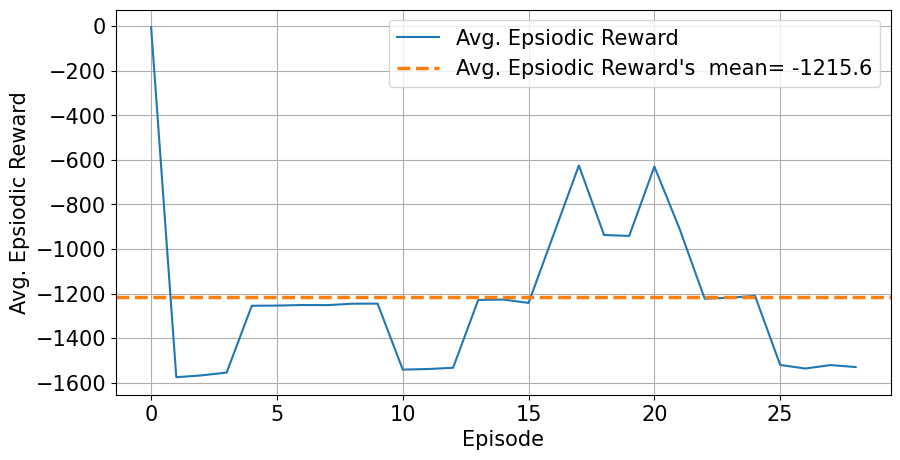

In [ ]:
# Plotting graph
# Episodes versus Avg. Rewards
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(avg_reward_list, label = "Avg. Epsiodic Reward",color="C0",linewidth = 1.5)
plt.axhline(y=np.array(avg_reward_list).mean(), linestyle='--',
            label = "Avg. Epsiodic Reward's  mean= "+f"{np.array(avg_reward_list).mean():.1f}",color="C1",linewidth = 2.5)
plt.xlabel("Episode")
plt.ylabel("Avg. Epsiodic Reward")
plt.grid()
plt.legend()
plt.show()

In [ ]:
print("Avg. Epsiodic Reward's mean=")
print(np.array(avg_reward_list).mean())

Avg. Epsiodic Reward's mean=
-1215.629266434646


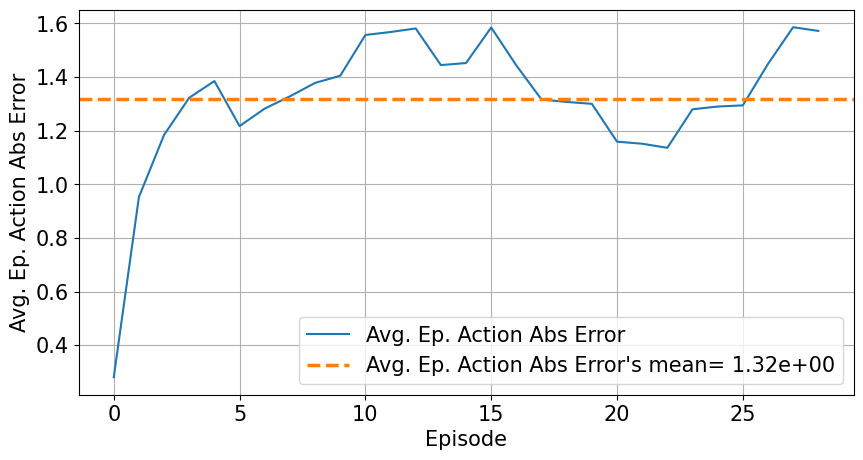

In [ ]:
if not env.ideal_env:
  font = {'size': 15}
  plt.rc('font', **font)
  f = plt.figure()
  f.set_figwidth(10)
  f.set_figheight(5)
  plt.plot(avg_ep_abs_error_action_list, label = "Avg. Ep. Action Abs Error",color="C0",linewidth = 1.5)
  plt.axhline(y=np.array(avg_ep_abs_error_action_list).mean(), linestyle='--',
            label = "Avg. Ep. Action Abs Error's mean= "+f"{np.array(avg_ep_abs_error_action_list).mean():.2e}",color="C1",linewidth = 2.5)
  plt.xlabel("Episode")
  plt.ylabel("Avg. Ep. Action Abs Error")
  plt.grid()
  plt.legend()
  plt.show()

In [ ]:
if not env.ideal_env:
  print("Avg. Ep. Action Abs Error's mean=")
  print(np.array(avg_ep_abs_error_action_list).mean())

Avg. Ep. Action Abs Error's mean=
1.3175121143963993


In [ ]:
dt = env.dt
#dt=0.05

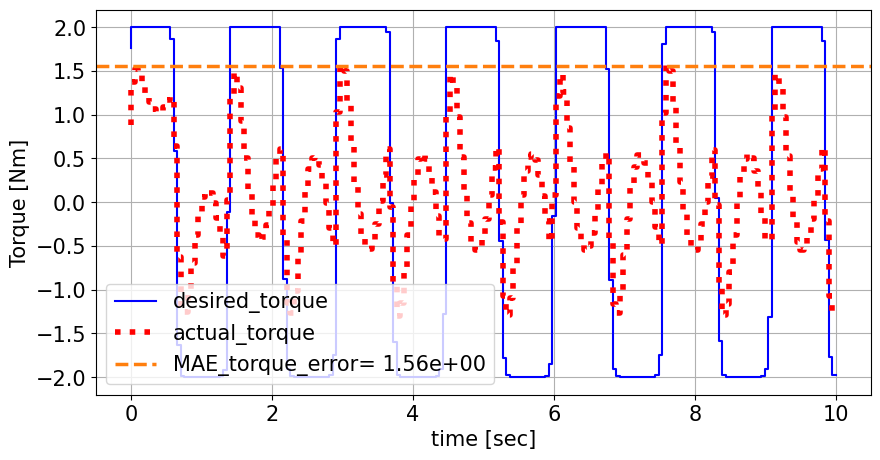

In [ ]:
time_position_u1= np.linspace(start = 0, stop = len(save_u1)* dt,num=len(save_u1) )
time_position__pid_u1= np.linspace(start = 0, stop = len(save_u1)* dt,num=len(save_u1) )

font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.step(time_position_u1, save_u1 ,label = "desired_torque",color="blue",linewidth = 1.5)
plt.xlabel("time [sec]")
plt.ylabel("Torque [Nm]")
if not env.ideal_env:
  plt.step(time_position__pid_u1, save_pid_u1 , ':',label = "actual_torque",color="red",linewidth = 4)
  mae_torque_error = np.array(save_u1)-np.array(save_pid_u1)
  mae_torque_error = np.abs(mae_torque_error).mean()
  plt.axhline(y=mae_torque_error, linestyle='--',
            label = "MAE_torque_error= "+f"{mae_torque_error:.2e}",color="C1",linewidth = 2.5)
  plt.legend()
plt.grid()
plt.show()

In [ ]:
if not env.ideal_env:
  print("MAE torque error=", mae_torque_error)

MAE torque error= 1.5557177820461772


In [ ]:
import math

x_print = []
y_print = []
thetadot_print = []

for observ in save_observation:
  for index,value in enumerate(observ):
    if index == 0:
      x_print.append(value)
      #theta_print.append(math.acos(value))
    if index == 1:
      y_print.append(value)
    if index == 2:
      thetadot_print.append(value)

theta_print = list(np.arctan2(np.array(y_print), np.array(x_print)))

In [ ]:
print(len(x_print))

200


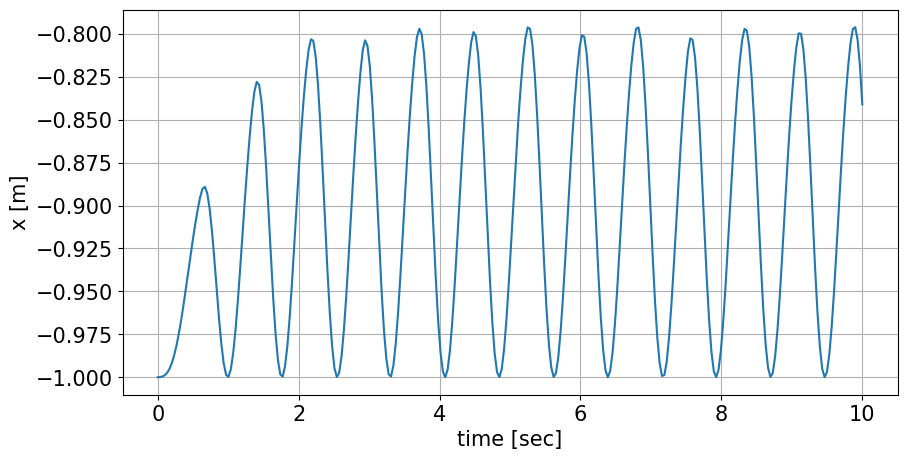

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_x_print = np.linspace(start = 0, stop = len(x_print)* dt,num=len(x_print))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_x_print[-1] , 300)

spl = make_interp_spline(time_x_print, x_print, k=3)  # type: BSpline
power_smooth = spl(xnew)

font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.plot(xnew, power_smooth)
plt.xlabel("time [sec]")
plt.ylabel("x [m]")
plt.grid()
plt.show()

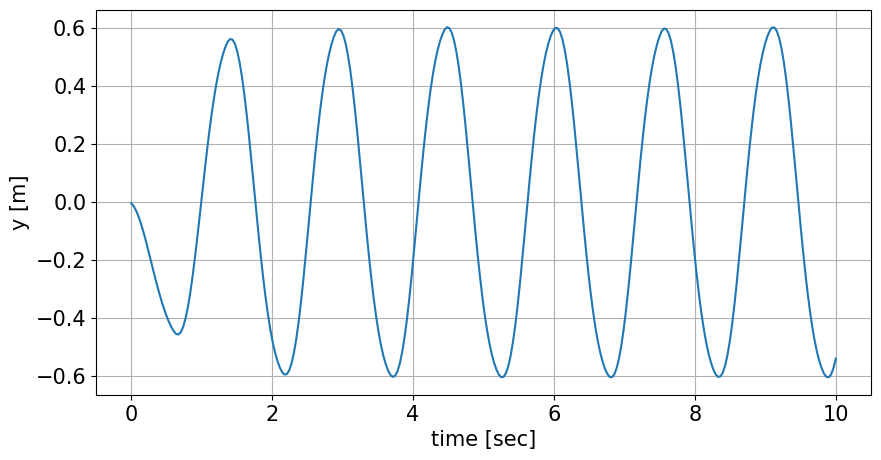

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_y_print = np.linspace(start = 0, stop = len(y_print)* dt,num=len(y_print))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_y_print[-1] , 300)

spl = make_interp_spline(time_y_print, y_print, k=3)  # type: BSpline
power_smooth = spl(xnew)

font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.plot(xnew, power_smooth)
plt.xlabel("time [sec]")
plt.ylabel("y [m]")
plt.grid()
plt.show()

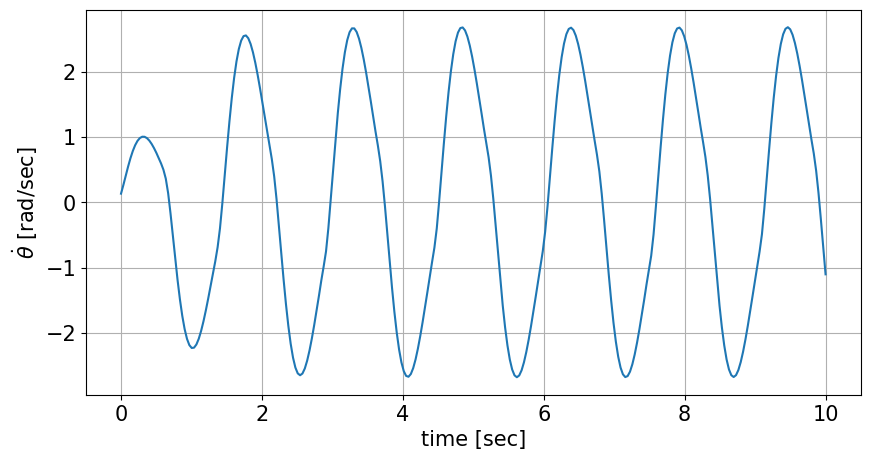

In [ ]:
from scipy.interpolate import make_interp_spline, BSpline

time_thetadot_print = np.linspace(start = 0, stop = len(thetadot_print)* dt,num=len(thetadot_print))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_thetadot_print[-1] , 300)

spl = make_interp_spline(time_thetadot_print, thetadot_print, k=3)  # type: BSpline
power_smooth = spl(xnew)

font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.plot(xnew, power_smooth)
plt.xlabel("time [sec]")
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.ylabel(r'$\dot{\theta}$ [rad/sec]')
plt.grid()
plt.show()

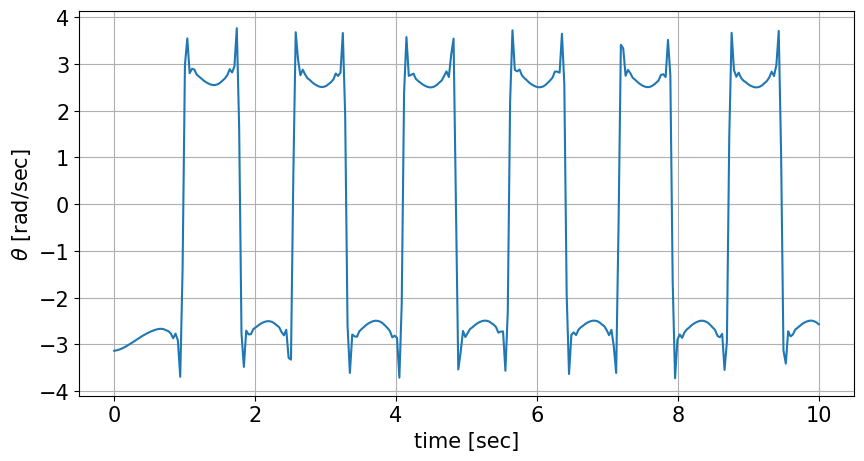

In [ ]:
time_theta_print = np.linspace(start = 0, stop = len(theta_print)* dt,num=len(theta_print))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_theta_print[-1] , 300)

spl = make_interp_spline(time_theta_print, theta_print, k=3)  # type: BSpline
power_smooth = spl(xnew)

font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)

plt.plot(xnew, power_smooth)
plt.xlabel("time [sec]")
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')
plt.ylabel(r'$\theta$ [rad/sec]')
plt.grid()
plt.show()